In [3]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import linregress
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:
warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style"
)

# 1. Población por edad y sexo
df_poblacion = pd.read_excel(
    "../Data/2026-07-20_INE_2026_2036_poblacion.xlsx",
    header=6
)

# 2. Saldo vegetativo
df_saldo_vegetativo = pd.read_excel(
    "../Data/2026-07-20_INE_2026_2075_saldo_vegetativo.xlsx",
    header=None,
    skiprows=6,
    names=[
        "periodo",
        "saldo_vegetativo_por_mil"
    ]
)

# Convertir ambas columnas a números
df_saldo_vegetativo["periodo"] = pd.to_numeric(
    df_saldo_vegetativo["periodo"],
    errors="coerce"
)

df_saldo_vegetativo["saldo_vegetativo_por_mil"] = pd.to_numeric(
    df_saldo_vegetativo["saldo_vegetativo_por_mil"],
    errors="coerce"
)

# Seleccionar solo 2026-2036
df_saldo_vegetativo = (
    df_saldo_vegetativo.loc[
        df_saldo_vegetativo["periodo"].between(
            2026,
            2036
        )
    ]
    .copy()
)

# Año como número entero
df_saldo_vegetativo["periodo"] = (
    df_saldo_vegetativo["periodo"].astype(int)
)

# Ordenar cronológicamente
df_saldo_vegetativo = (
    df_saldo_vegetativo
    .sort_values("periodo")
    .reset_index(drop=True)
)


# 3. Migración neta
df_migracion_neta = pd.read_excel(
    "../Data/2026-07-20_INE_2026-2075_migracion_neta.xlsx",
    header=None,
    skiprows=6,
    names=[
        "periodo",
        "tasa_migracion_neta"
    ]
)

# convertir datos
df_migracion_neta["periodo"] = pd.to_numeric(
    df_migracion_neta["periodo"],
    errors="coerce"
)

df_migracion_neta["tasa_migracion_neta"] = pd.to_numeric(
    df_migracion_neta["tasa_migracion_neta"],
    errors="coerce"
)

# decada ordenada
df_migracion_neta = (
    df_migracion_neta.loc[
        df_migracion_neta["periodo"].between(
            2026,
            2036
        )
    ]
    .copy()
)

df_migracion_neta["periodo"] = (
    df_migracion_neta["periodo"].astype(int)
)

df_migracion_neta = (
    df_migracion_neta
    .sort_values("periodo")
    .reset_index(drop=True)
)


display(df_poblacion.head())
display(df_saldo_vegetativo.head())
display(df_migracion_neta.head())

,,2076,2075,2074,2073,2072,2071,2070,2069,2068,...,2035,2034,2033,2032,2031,2030,2029,2028,2027,2026
0,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Todas las edades,5.297299e+07,5.302801e+07,5.308861e+07,5.315315e+07,5.322143e+07,5.329357e+07,5.336974e+07,5.344987e+07,5.353358e+07,...,5.288414e+07,5.265876e+07,5.240291e+07,5.211205e+07,5.178245e+07,5.141203e+07,5.100118e+07,5.055393e+07,5.007877e+07,49590099.0
2,0 años,3.555469e+05,3.548414e+05,3.539143e+05,3.527670e+05,3.514238e+05,3.499194e+05,3.482985e+05,3.466060e+05,3.448875e+05,...,3.613875e+05,3.569122e+05,3.524054e+05,3.478817e+05,3.433373e+05,3.387731e+05,3.342223e+05,3.297576e+05,3.255249e+05,323425.0
3,1 año,3.584631e+05,3.575461e+05,3.564309e+05,3.551247e+05,3.536552e+05,3.520659e+05,3.504023e+05,3.487126e+05,3.470484e+05,...,3.621268e+05,3.579681e+05,3.538438e+05,3.497394e+05,3.456374e+05,3.415435e+05,3.374931e+05,3.335851e+05,3.316380e+05,324651.0
4,2 años,3.611875e+05,3.600844e+05,3.588126e+05,3.573823e+05,3.558296e+05,3.541985e+05,3.525382e+05,3.509025e+05,3.493458e+05,...,3.632257e+05,3.594418e+05,3.557263e+05,3.520507e+05,3.484016e+05,3.447869e+05,3.412688e+05,3.395938e+05,3.329214e+05,330814.0


,periodo,saldo_vegetativo_por_mil
0,2026,-2.542558
1,2027,-2.529663
2,2028,-2.517906
3,2029,-2.507789
4,2030,-2.504546


,periodo,tasa_migracion_neta
0,2026,12.348410
1,2027,11.973166
2,2028,11.325929
3,2029,10.531064
4,2030,9.683639


In [5]:
print("Población:", df_poblacion.shape)
print("Saldo vegetativo:", df_saldo_vegetativo.shape)
print("Migración neta:", df_migracion_neta.shape)

Población: (315, 52)
Saldo vegetativo: (11, 2)
Migración neta: (11, 2)


In [6]:
# renombra columna edad
df_poblacion = df_poblacion.rename(columns={df_poblacion.columns[0]: "edad"})

# limpiar espacios
df_poblacion["edad"] = df_poblacion["edad"].astype(str).str.strip()

# bloque total
inicio = df_poblacion.index[df_poblacion["edad"] == "Todas las edades"][0]
fin = df_poblacion.index[df_poblacion["edad"] == "Hombres"][0]

df_total = df_poblacion.loc[inicio:fin - 1].copy()

# decada
df_poblacion.columns = df_poblacion.columns.astype(str)

columnas = ["edad"] + [str(año) for año in range(2026, 2037)]

df_total = df_total[columnas]

display(df_total.head())


,edad,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036
1,Todas las edades,49590099.0,5.007877e+07,5.055393e+07,5.100118e+07,5.141203e+07,5.178245e+07,5.211205e+07,5.240291e+07,5.265876e+07,5.288414e+07,5.308394e+07
2,0 años,323425.0,3.255249e+05,3.297576e+05,3.342223e+05,3.387731e+05,3.433373e+05,3.478817e+05,3.524054e+05,3.569122e+05,3.613875e+05,3.657939e+05
3,1 año,324651.0,3.316380e+05,3.335851e+05,3.374931e+05,3.415435e+05,3.456374e+05,3.497394e+05,3.538438e+05,3.579681e+05,3.621268e+05,3.663093e+05
4,2 años,330814.0,3.329214e+05,3.395938e+05,3.412688e+05,3.447869e+05,3.484016e+05,3.520507e+05,3.557263e+05,3.594418e+05,3.632257e+05,3.670972e+05
5,3 años,350186.0,3.387151e+05,3.406227e+05,3.468626e+05,3.482119e+05,3.513316e+05,3.545363e+05,3.577899e+05,3.611029e+05,3.644998e+05,3.680141e+05


In [7]:
df_poblacion_edades = df_total.copy()

# Extraer edad numérica
df_poblacion_edades["edad_num"] = (
    df_poblacion_edades["edad"]
    .str.extract(r"(\d+)")
    .astype(float)
)

# Seleccionar población de 18 a 100+ años
df_poblacion_edades = (
    df_poblacion_edades.loc[
        df_poblacion_edades["edad_num"]
        .between(18, 120)
    ]
    .copy()
)

df_poblacion_edades["edad_num"] = (
    df_poblacion_edades["edad_num"].astype(int)
)

# Años que queremos analizar
años = [str(año) for año in range(2026, 2037)]

# Crear una nueva tabla en formato largo
df_poblacion_larga = df_poblacion_edades.melt(
    id_vars=["edad_num"],
    value_vars=años,
    var_name="periodo",
    value_name="poblacion"
)

# Convertir tipos
df_poblacion_larga["periodo"] = (
    df_poblacion_larga["periodo"].astype(int)
)

df_poblacion_larga["poblacion"] = pd.to_numeric(
    df_poblacion_larga["poblacion"],
    errors="coerce"
)

# Ordenar
df_poblacion_larga = (
    df_poblacion_larga
    .sort_values(["periodo", "edad_num"])
    .reset_index(drop=True)
)

display(df_poblacion_larga.head())

,edad_num,periodo,poblacion
0,18,2026,551342.0
1,19,2026,559068.0
2,20,2026,553819.0
3,21,2026,557615.0
4,22,2026,557311.0


In [8]:
print("Dimensiones:", df_poblacion_larga.shape)
print("Edad mínima:", df_poblacion_larga["edad_num"].min())
print("Edad máxima:", df_poblacion_larga["edad_num"].max())
print("Periodo mínimo:", df_poblacion_larga["periodo"].min())
print("Periodo máximo:", df_poblacion_larga["periodo"].max())

Dimensiones: (913, 3)
Edad mínima: 18
Edad máxima: 100
Periodo mínimo: 2026
Periodo máximo: 2036


In [9]:
print(df_poblacion.shape)
print(df_saldo_vegetativo.shape)
print(df_migracion_neta.shape)

(315, 52)
(11, 2)
(11, 2)


# Estadistica descriptiva

In [10]:
df_poblacion_larga.groupby("periodo")["poblacion"].describe()

,count,mean,std,min,25%,50%,75%,max
periodo,,,,,,,,
2026,83.0,502735.855422,238806.071811,12530.000000,360272.000000,559068.000000,673314.500000,839091.000000
2027,83.0,509812.720332,239454.995094,13175.017358,361689.469317,575068.716919,676527.076115,842587.063285
2028,83.0,516586.645872,239963.650342,14975.043599,379689.891372,590536.531391,679146.044974,845565.810692
2029,83.0,523041.035297,240282.793997,15765.660749,389075.757429,604484.919764,682241.025883,847871.003096
2030,83.0,529036.279850,240349.276828,17511.209708,380169.767754,617988.317962,689055.694761,849403.405286
2031,83.0,534507.443451,240137.794806,18058.301544,376432.485178,629509.678964,692237.555173,850156.642239
2032,83.0,539262.533038,239642.093500,19938.898251,392324.843167,637901.540737,692346.279067,850152.950691
2033,83.0,543666.649541,238872.665466,20793.637058,405336.326456,645671.711389,688450.244495,849420.217372
2034,83.0,547607.852563,237853.676323,21246.081937,406382.902923,651671.287652,684609.795860,847963.572009


## Segmentación por grupos de edad

Las proyecciones del INE proporcionan la población desagregada por cada edad individual (18, 19, 20, ..., 100 años). Sin embargo, para responder a la pregunta de negocio resulta más útil agrupar las edades en segmentos que representen diferentes etapas del ciclo de vida.

Esta segmentación permite analizar cómo evolucionará el tamaño de cada grupo de clientes potenciales durante los próximos años.

Los segmentos definidos son:

- **18-24 años:** Jóvenes.
- **25-34 años:** Jóvenes adultos.
- **35-44 años:** Adultos iniciales.
- **45-54 años:** Adultos maduros.
- **55-64 años:** Mediana edad.
- **65+ años:** Sénior.

Estos grupos reflejan diferentes necesidades financieras y permiten relacionar posteriormente la información demográfica con el comportamiento financiero obtenido de la Encuesta de Competencias Financieras (ECF).

Una vez creada la variable *segmento_edad*, se agrupa la población por año y segmento para conocer cuántas personas pertenecen a cada grupo en cada periodo.

In [11]:
# Copia del dataframe
df_segmentos = df_poblacion_larga.copy()

# Crear segmentos de edad
df_segmentos["segmento_edad"] = pd.cut(
    df_segmentos["edad_num"],
    bins=[17,24,34,44,54,64,120],
    labels=[
        "18-24 Jóvenes",
        "25-34 Jóvenes adultos",
        "35-44 Adultos iniciales",
        "45-54 Adultos maduros",
        "55-64 Mediana edad",
        "65+ Sénior"
    ]
)

# Agrupar población por año y segmento
df_segmentos_edad = (
    df_segmentos
    .groupby(["periodo","segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

display(df_segmentos_edad.head(6))

,periodo,segmento_edad,poblacion
0,2026,18-24 Jóvenes,3878454.0
1,2026,25-34 Jóvenes adultos,5689845.0
2,2026,35-44 Adultos iniciales,6526108.0
3,2026,45-54 Adultos maduros,8071195.0
4,2026,55-64 Mediana edad,7122580.0
5,2026,65+ Sénior,10438894.0


## Peso relativo de cada segmento poblacional

Conocer el número absoluto de personas en cada segmento resulta útil, pero no permite apreciar fácilmente cómo cambia la estructura de la población.

Por ello se calcula el peso porcentual que representa cada segmento respecto al total de la población proyectada para cada año.

Este indicador permite responder preguntas como:

- ¿Qué porcentaje de la población serán jóvenes dentro de diez años?
- ¿Aumentará el peso de la población sénior?
- ¿Qué segmentos perderán importancia relativa?

Este análisis facilita comparar años diferentes aunque la población total aumente o disminuya.

In [12]:
totales = (
    df_segmentos_edad
    .groupby("periodo")["poblacion"]
    .sum()
    .rename("total")
)

df_segmentos_edad = (
    df_segmentos_edad
    .merge(totales, on="periodo")
)

df_segmentos_edad["porcentaje"] = (
    df_segmentos_edad["poblacion"]
    / df_segmentos_edad["total"]
    *100
)

display(df_segmentos_edad)

,periodo,segmento_edad,poblacion,total,porcentaje
0,2026,18-24 Jóvenes,3.878454e+06,4.172708e+07,9.294814
1,2026,25-34 Jóvenes adultos,5.689845e+06,4.172708e+07,13.635858
2,2026,35-44 Adultos iniciales,6.526108e+06,4.172708e+07,15.639984
3,2026,45-54 Adultos maduros,8.071195e+06,4.172708e+07,19.342824
4,2026,55-64 Mediana edad,7.122580e+06,4.172708e+07,17.069444
...,...,...,...,...,...
61,2036,25-34 Jóvenes adultos,6.850573e+06,4.598461e+07,14.897534
62,2036,35-44 Adultos iniciales,6.689109e+06,4.598461e+07,14.546410
63,2036,45-54 Adultos maduros,7.101191e+06,4.598461e+07,15.442539
64,2036,55-64 Mediana edad,8.098875e+06,4.598461e+07,17.612144


## Composición porcentual de la población por segmentos de edad

Además de analizar la evolución absoluta de la población, resulta fundamental estudiar cómo cambia la composición relativa de los distintos segmentos de edad a lo largo del periodo analizado.

Para ello se calcula el porcentaje que representa cada segmento sobre la población total proyectada en cada año y se representa mediante un gráfico de barras apiladas al 100%.

Esta visualización permite identificar qué segmentos ganan o pierden peso dentro del conjunto de la población, independientemente de que la población total aumente o disminuya.

Desde una perspectiva de negocio, este análisis responde directamente a la pregunta planteada en el proyecto, ya que permite evaluar si la estructura del mercado potencial evolucionará de forma significativa y, en consecuencia, si resulta conveniente redefinir los segmentos de clientes o adaptar la oferta de productos financieros a los cambios demográficos previstos.

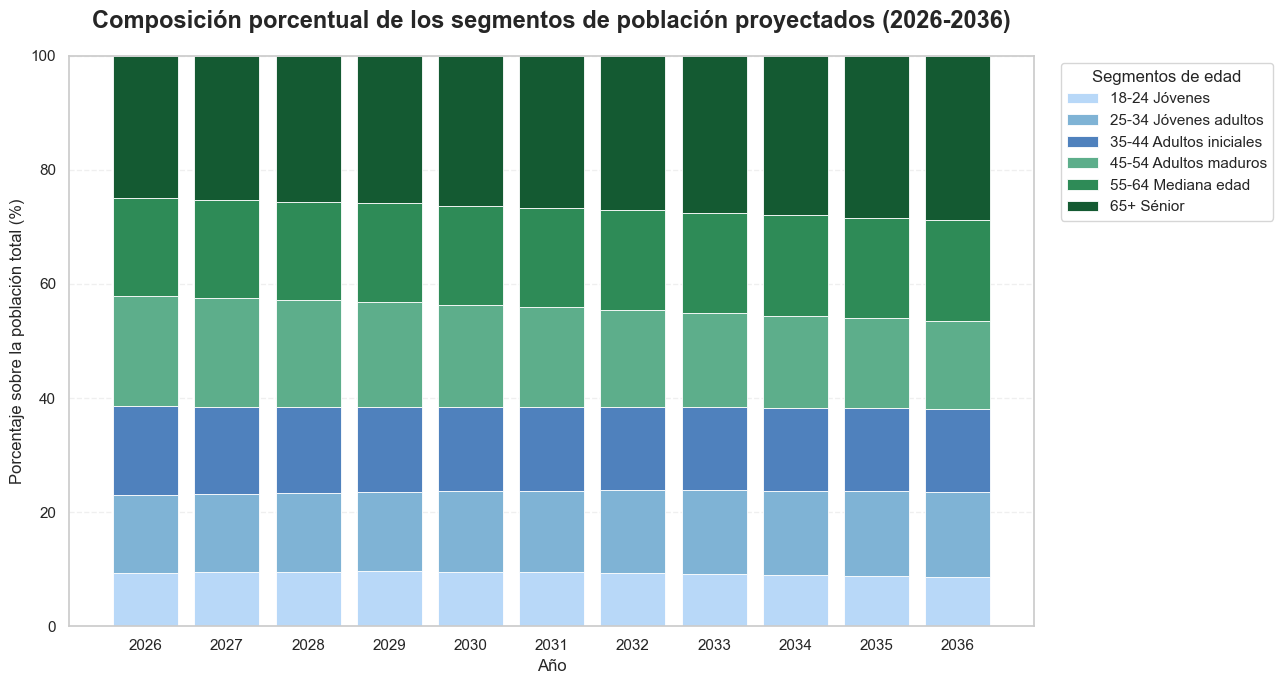

In [13]:
# =====================================================
# COMPOSICIÓN PORCENTUAL DE LOS SEGMENTOS
# (STACKED BAR 100%)
# =====================================================

sns.set_theme(style="whitegrid")

# Agrupar población por año y segmento
df_comp = (
    df_segmentos_edad
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Total anual
df_comp["total"] = (
    df_comp
    .groupby("periodo")["poblacion"]
    .transform("sum")
)

# Porcentaje
df_comp["porcentaje"] = (
    df_comp["poblacion"]
    / df_comp["total"]
    * 100
)

# Tabla dinámica
pivot = (
    df_comp
    .pivot(
        index="periodo",
        columns="segmento_edad",
        values="porcentaje"
    )
)

# Orden de segmentos
orden = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior"
]

pivot = pivot[orden]

# Colores corporativos
colores = [
    "#B8D8F8",
    "#7FB3D5",
    "#4F81BD",
    "#5DAE8B",
    "#2E8B57",
    "#145A32"
]

# =====================================================
# GRÁFICO
# =====================================================

fig, ax = plt.subplots(figsize=(13,7))

acumulado = [0] * len(pivot)

for color, segmento in zip(colores, pivot.columns):

    ax.bar(
        pivot.index.astype(str),
        pivot[segmento],
        bottom=acumulado,
        label=segmento,
        color=color,
        edgecolor="white",
        linewidth=0.6
    )

    acumulado += pivot[segmento].values

ax.set_ylim(0,100)

ax.set_title(
    "Composición porcentual de los segmentos de población proyectados (2026-2036)",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Año", fontsize=12)

ax.set_ylabel(
    "Porcentaje sobre la población total (%)",
    fontsize=12
)

ax.legend(
    title="Segmentos de edad",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

# Crecimiento absoluto y crecimiento porcentual
## Evolución de los segmentos poblacionales

Una vez definidos los segmentos, se analiza cómo evolucionan entre el primer y el último año disponible en la proyección.

Se calculan dos indicadores:

- **Crecimiento absoluto:** diferencia en el número de personas entre ambos años.
- **Crecimiento porcentual:** porcentaje de crecimiento o disminución respecto al año inicial.

El crecimiento absoluto muestra cuántas personas gana o pierde cada segmento.

El crecimiento porcentual permite comparar segmentos de distinto tamaño, identificando cuáles experimentan un mayor crecimiento relativo.

Estos indicadores permiten detectar qué grupos de población aumentarán y cuáles disminuirán, información fundamental para decidir si es necesario redefinir los segmentos de clientes de la empresa.

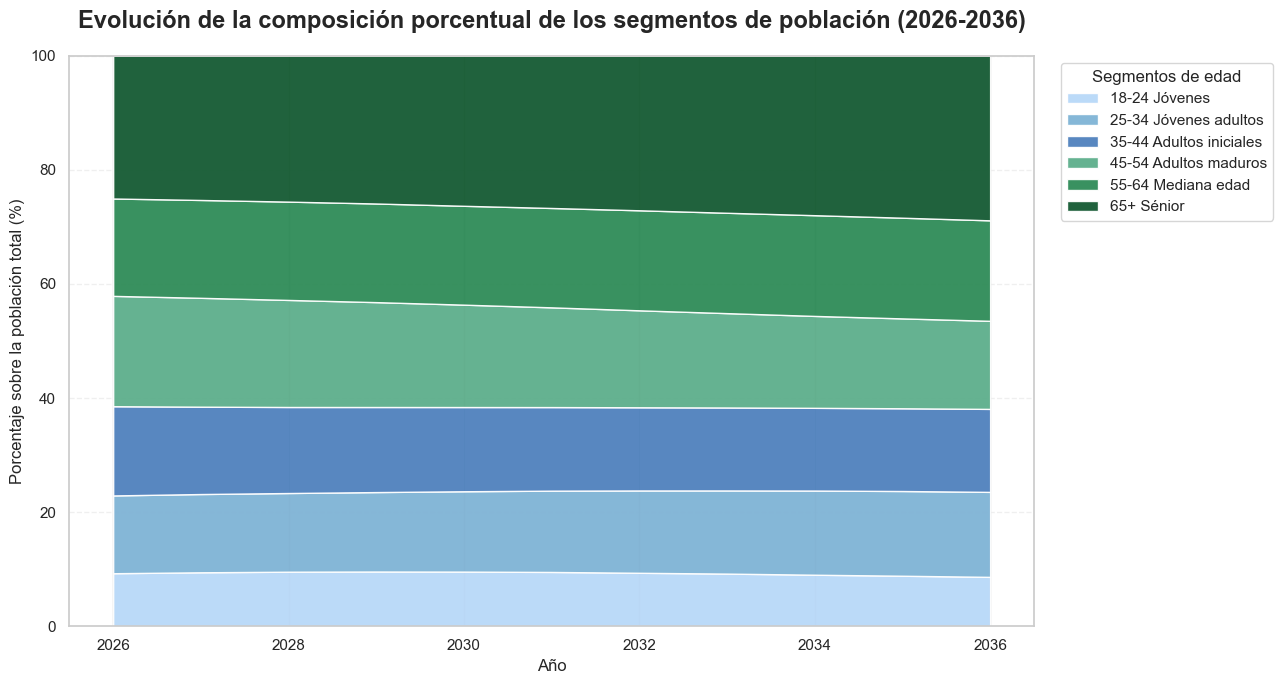

In [14]:
# =====================================================
# COMPOSICIÓN PORCENTUAL DE LOS SEGMENTOS DE EDAD
# =====================================================

sns.set_theme(style="whitegrid")

# Agrupar población por año y segmento
df_comp = (
    df_segmentos_edad
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Calcular porcentaje sobre el total anual
df_comp["total"] = (
    df_comp
    .groupby("periodo")["poblacion"]
    .transform("sum")
)

df_comp["porcentaje"] = (
    df_comp["poblacion"]
    / df_comp["total"]
    * 100
)

# Tabla dinámica
pivot = (
    df_comp
    .pivot(
        index="periodo",
        columns="segmento_edad",
        values="porcentaje"
    )
)

# Mantener el orden de los segmentos
orden = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior"
]

pivot = pivot[orden]

# Colores corporativos
colores = [
    "#B8D8F8",   # Azul muy claro
    "#7FB3D5",   # Azul claro
    "#4F81BD",   # Azul medio
    "#5DAE8B",   # Verde azulado
    "#2E8B57",   # Verde corporativo
    "#145A32"    # Verde oscuro
]

# =====================================================
# GRÁFICO
# =====================================================

plt.figure(figsize=(13,7))

plt.stackplot(
    pivot.index,
    pivot.T.values,
    labels=pivot.columns,
    colors=colores,
    alpha=0.95
)

plt.title(
    "Evolución de la composición porcentual de los segmentos de población (2026-2036)",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Año", fontsize=12)
plt.ylabel("Porcentaje sobre la población total (%)", fontsize=12)

plt.ylim(0,100)

plt.legend(
    title="Segmentos de edad",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Heatmap de la población proyectada por edad

Con el objetivo de complementar el análisis temporal, se representa la población proyectada mediante un mapa de calor (*heatmap*), donde cada fila corresponde a una edad y cada columna a un año del periodo analizado.

La intensidad del color representa el volumen de población proyectado para cada combinación de edad y año.

Este tipo de visualización permite identificar de forma inmediata los grupos de edad que concentran una mayor población y observar cómo evolucionan a lo largo del horizonte temporal.

A diferencia de los gráficos de líneas, el heatmap facilita la detección de patrones demográficos, desplazamientos entre cohortes de edad y cambios en la estructura poblacional.

Desde una perspectiva de negocio, esta representación permite identificar visualmente qué edades ganarán relevancia como mercado potencial y cuáles perderán peso durante los próximos años, aportando información útil para la redefinición de segmentos de clientes y la adaptación de la oferta de productos financieros.

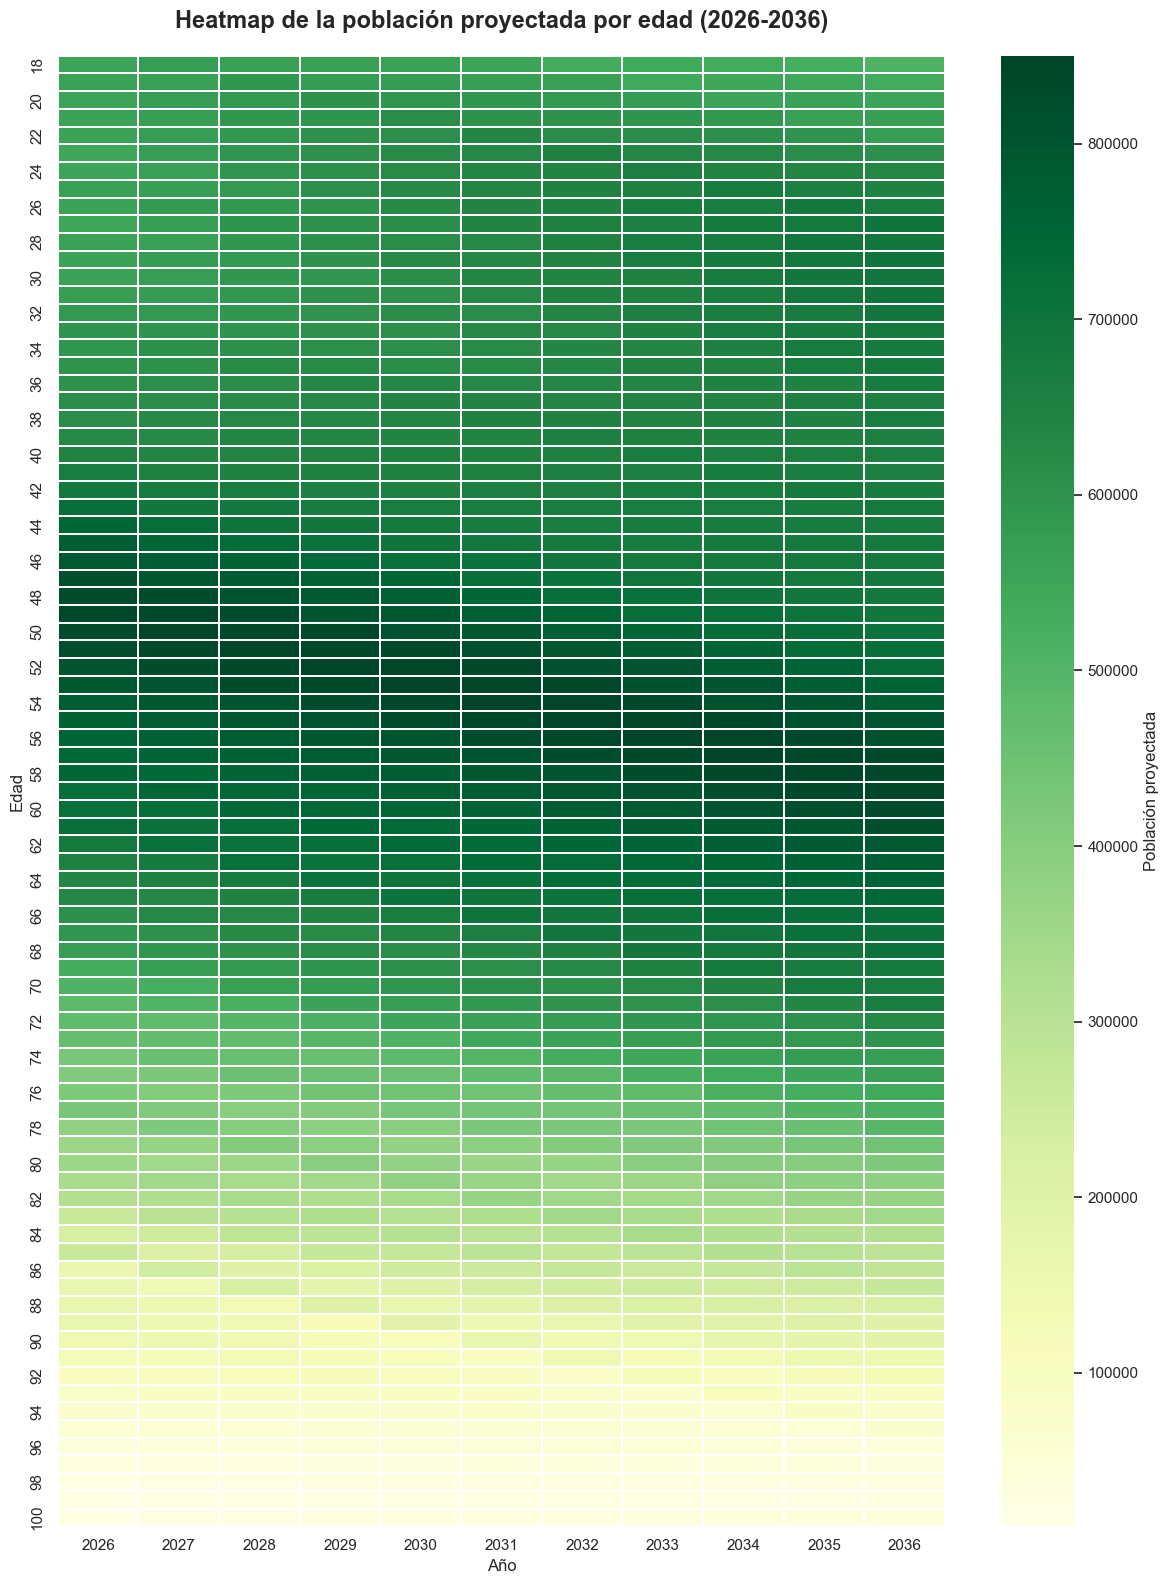

In [15]:
# =====================================================
# HEATMAP DE LA POBLACIÓN PROYECTADA POR EDAD
# =====================================================

# Crear matriz Edad × Año
heatmap_data = (
    df_poblacion_larga
    .pivot(
        index="edad_num",
        columns="periodo",
        values="poblacion"
    )
)

sns.set_theme(style="white")

plt.figure(figsize=(12, 16))

sns.heatmap(
    heatmap_data,
    cmap="YlGn",
    linewidths=0.05,
    linecolor="white",
    cbar_kws={"label": "Población proyectada"}
)

plt.title(
    "Heatmap de la población proyectada por edad (2026-2036)",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Año", fontsize=12)
plt.ylabel("Edad", fontsize=12)

plt.tight_layout()

plt.show()

# Crecimiento absoluto y crecimiento porcentual
## Evolución de los segmentos poblacionales

Una vez definidos los segmentos, se analiza cómo evolucionan entre el primer y el último año disponible en la proyección.

Se calculan dos indicadores:

- **Crecimiento absoluto:** diferencia en el número de personas entre ambos años.
- **Crecimiento porcentual:** porcentaje de crecimiento o disminución respecto al año inicial.

El crecimiento absoluto muestra cuántas personas gana o pierde cada segmento.

El crecimiento porcentual permite comparar segmentos de distinto tamaño, identificando cuáles experimentan un mayor crecimiento relativo.

Estos indicadores permiten detectar qué grupos de población aumentarán y cuáles disminuirán, información fundamental para decidir si es necesario redefinir los segmentos de clientes de la empresa.

# Crecimiento absoluto

In [16]:
df_crecimiento = (
    df_segmentos_edad
    .pivot(
        index="segmento_edad",
        columns="periodo",
        values="poblacion"
    )
)

df_crecimiento["crecimiento_absoluto"] = (
    df_crecimiento[2036]
    - df_crecimiento[2026]
)

display(df_crecimiento)

periodo,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,crecimiento_absoluto
segmento_edad,,,,,,,,,,,,
18-24 Jóvenes,3878454.0,4.002649e+06,4.100102e+06,4.166547e+06,4.206732e+06,4.223637e+06,4.195619e+06,4.165050e+06,4.105946e+06,4.051151e+06,3.980563e+06,1.021087e+05
25-34 Jóvenes adultos,5689845.0,5.804328e+06,5.913587e+06,6.044268e+06,6.184294e+06,6.321412e+06,6.458615e+06,6.577189e+06,6.706231e+06,6.792953e+06,6.850573e+06,1.160728e+06
35-44 Adultos iniciales,6526108.0,6.479453e+06,6.466621e+06,6.473977e+06,6.482370e+06,6.500020e+06,6.525927e+06,6.562390e+06,6.590409e+06,6.632945e+06,6.689109e+06,1.630013e+05
45-54 Adultos maduros,8071195.0,8.075960e+06,8.045868e+06,7.980870e+06,7.880490e+06,7.755446e+06,7.608178e+06,7.463157e+06,7.322954e+06,7.206143e+06,7.101191e+06,-9.700041e+05
55-64 Mediana edad,7122580.0,7.256752e+06,7.389719e+06,7.505974e+06,7.609673e+06,7.728139e+06,7.848202e+06,7.938794e+06,8.025321e+06,8.074426e+06,8.098875e+06,9.762954e+05
65+ Sénior,10438894.0,1.069531e+07,1.096080e+07,1.124077e+07,1.154645e+07,1.183546e+07,1.212225e+07,1.241775e+07,1.270059e+07,1.298264e+07,1.326430e+07,2.825402e+06


# Crecimiento porcentual

In [17]:
df_crecimiento["crecimiento_%"] = (
    (
        df_crecimiento[2036]
        - df_crecimiento[2026]
    )
    /
    df_crecimiento[2026]
    *100
)

display(df_crecimiento)

periodo,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,crecimiento_absoluto,crecimiento_%
segmento_edad,,,,,,,,,,,,,
18-24 Jóvenes,3878454.0,4.002649e+06,4.100102e+06,4.166547e+06,4.206732e+06,4.223637e+06,4.195619e+06,4.165050e+06,4.105946e+06,4.051151e+06,3.980563e+06,1.021087e+05,2.632716
25-34 Jóvenes adultos,5689845.0,5.804328e+06,5.913587e+06,6.044268e+06,6.184294e+06,6.321412e+06,6.458615e+06,6.577189e+06,6.706231e+06,6.792953e+06,6.850573e+06,1.160728e+06,20.399985
35-44 Adultos iniciales,6526108.0,6.479453e+06,6.466621e+06,6.473977e+06,6.482370e+06,6.500020e+06,6.525927e+06,6.562390e+06,6.590409e+06,6.632945e+06,6.689109e+06,1.630013e+05,2.497680
45-54 Adultos maduros,8071195.0,8.075960e+06,8.045868e+06,7.980870e+06,7.880490e+06,7.755446e+06,7.608178e+06,7.463157e+06,7.322954e+06,7.206143e+06,7.101191e+06,-9.700041e+05,-12.018098
55-64 Mediana edad,7122580.0,7.256752e+06,7.389719e+06,7.505974e+06,7.609673e+06,7.728139e+06,7.848202e+06,7.938794e+06,8.025321e+06,8.074426e+06,8.098875e+06,9.762954e+05,13.707047
65+ Sénior,10438894.0,1.069531e+07,1.096080e+07,1.124077e+07,1.154645e+07,1.183546e+07,1.212225e+07,1.241775e+07,1.270059e+07,1.298264e+07,1.326430e+07,2.825402e+06,27.066107


## Variación porcentual anual

Hasta este punto se ha analizado la evolución total de cada segmento entre el primer y el último año del periodo de estudio. Sin embargo, este enfoque no permite identificar si el crecimiento o la disminución de la población se produce de forma constante o si existen años en los que la variación se acelera o se ralentiza.

Por ello, se calcula la **variación porcentual anual**, que mide el cambio relativo de la población entre dos años consecutivos.

La variación porcentual anual se calcula mediante la siguiente expresión:

\[
Variación\ (\%)=\frac{Población_{año\ actual}-Población_{año\ anterior}}
{Población_{año\ anterior}}\times100
\]

Este análisis permite:

- Identificar años con mayores incrementos o descensos de población.
- Detectar posibles aceleraciones o desaceleraciones en el crecimiento de cada segmento.
- Analizar si la evolución demográfica sigue una tendencia estable o presenta cambios significativos a lo largo del periodo estudiado.

La información obtenida complementa el análisis del crecimiento total y facilita una interpretación más detallada de la evolución de cada segmento poblacional.

In [18]:
# Crear una copia
df_variacion = df_segmentos_edad.copy()

# Ordenar por segmento y año
df_variacion = df_variacion.sort_values(
    ["segmento_edad", "periodo"]
)

# Calcular la variación porcentual anual
df_variacion["variacion_anual_%"] = (
    df_variacion
    .groupby("segmento_edad")["poblacion"]
    .pct_change() * 100
)

# Redondear
df_variacion["variacion_anual_%"] = (
    df_variacion["variacion_anual_%"]
    .round(2)
)

display(df_variacion)

,periodo,segmento_edad,poblacion,total,porcentaje,variacion_anual_%
0,2026,18-24 Jóvenes,3.878454e+06,4.172708e+07,9.294814,NaN
6,2027,18-24 Jóvenes,4.002649e+06,4.231446e+07,9.459294,3.20
12,2028,18-24 Jóvenes,4.100102e+06,4.287669e+07,9.562543,2.43
18,2029,18-24 Jóvenes,4.166547e+06,4.341241e+07,9.597595,1.62
24,2030,18-24 Jóvenes,4.206732e+06,4.391001e+07,9.580349,0.96
...,...,...,...,...,...,...
41,2032,65+ Sénior,1.212225e+07,4.475879e+07,27.083503,2.42
47,2033,65+ Sénior,1.241775e+07,4.512433e+07,27.518971,2.44
53,2034,65+ Sénior,1.270059e+07,4.545145e+07,27.943202,2.28
59,2035,65+ Sénior,1.298264e+07,4.574026e+07,28.383402,2.22


## Tasa de Crecimiento Anual Compuesta (CAGR)

Aunque el crecimiento absoluto y porcentual muestran la variación total entre el primer y el último año del estudio, no indican cuál ha sido el ritmo medio de crecimiento de cada segmento a lo largo del periodo.

Para ello se calcula la **Tasa de Crecimiento Anual Compuesta (Compound Annual Growth Rate, CAGR)**.

El CAGR representa el porcentaje medio al que habría crecido (o disminuido) un segmento cada año si su evolución hubiera sido constante durante todo el periodo analizado.

Su cálculo se realiza mediante la siguiente expresión:

\[
CAGR=\left(\frac{Valor\ Final}{Valor\ Inicial}\right)^{1/n}-1
\]

donde:

- **Valor Inicial:** población del segmento en el primer año del estudio.
- **Valor Final:** población del segmento en el último año.
- **n:** número de años transcurridos.

Este indicador permite comparar el ritmo de crecimiento de segmentos con tamaños muy diferentes y facilita identificar cuáles presentan una evolución demográfica más favorable desde una perspectiva de negocio.

**La interpretación sería:**

Un CAGR positivo indica que el segmento crece de forma sostenida cada año.
Un CAGR negativo indica una disminución progresiva del segmento.
Cuanto mayor sea el valor del CAGR, mayor será el ritmo medio de crecimiento anual.

In [19]:
# Número de años entre la primera y la última proyección
n_anios = 2036 - 2026

# Cálculo del CAGR
df_crecimiento["CAGR (%)"] = (
    (
        df_crecimiento[2036] / df_crecimiento[2026]
    ) ** (1 / n_anios) - 1
) * 100

# Redondear a dos decimales
df_crecimiento["CAGR (%)"] = df_crecimiento["CAGR (%)"].round(2)

display(df_crecimiento)

periodo,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,crecimiento_absoluto,crecimiento_%,CAGR (%)
segmento_edad,,,,,,,,,,,,,,
18-24 Jóvenes,3878454.0,4.002649e+06,4.100102e+06,4.166547e+06,4.206732e+06,4.223637e+06,4.195619e+06,4.165050e+06,4.105946e+06,4.051151e+06,3.980563e+06,1.021087e+05,2.632716,0.26
25-34 Jóvenes adultos,5689845.0,5.804328e+06,5.913587e+06,6.044268e+06,6.184294e+06,6.321412e+06,6.458615e+06,6.577189e+06,6.706231e+06,6.792953e+06,6.850573e+06,1.160728e+06,20.399985,1.87
35-44 Adultos iniciales,6526108.0,6.479453e+06,6.466621e+06,6.473977e+06,6.482370e+06,6.500020e+06,6.525927e+06,6.562390e+06,6.590409e+06,6.632945e+06,6.689109e+06,1.630013e+05,2.497680,0.25
45-54 Adultos maduros,8071195.0,8.075960e+06,8.045868e+06,7.980870e+06,7.880490e+06,7.755446e+06,7.608178e+06,7.463157e+06,7.322954e+06,7.206143e+06,7.101191e+06,-9.700041e+05,-12.018098,-1.27
55-64 Mediana edad,7122580.0,7.256752e+06,7.389719e+06,7.505974e+06,7.609673e+06,7.728139e+06,7.848202e+06,7.938794e+06,8.025321e+06,8.074426e+06,8.098875e+06,9.762954e+05,13.707047,1.29
65+ Sénior,10438894.0,1.069531e+07,1.096080e+07,1.124077e+07,1.154645e+07,1.183546e+07,1.212225e+07,1.241775e+07,1.270059e+07,1.298264e+07,1.326430e+07,2.825402e+06,27.066107,2.42


## Ranking de segmentos poblacionales

Una vez analizada la evolución de cada segmento mediante el crecimiento absoluto, el crecimiento porcentual y la tasa de crecimiento anual compuesta (CAGR), resulta útil sintetizar los resultados en un ranking que facilite su interpretación desde una perspectiva de negocio.

El objetivo de este análisis es identificar qué segmentos presentan una evolución más favorable y cuáles muestran una pérdida de peso dentro de la población proyectada.

Para ello se ordenan los segmentos según tres indicadores:

- **Mayor crecimiento absoluto:** número de personas que gana o pierde cada segmento entre el primer y el último año del estudio.
- **Mayor crecimiento porcentual:** crecimiento relativo respecto al tamaño inicial del segmento.
- **Mayor peso poblacional:** porcentaje que representa cada segmento sobre la población total en el último año de la proyección.

Este ranking permite detectar qué grupos de población tendrán una mayor relevancia en el futuro y facilita la toma de decisiones estratégicas relacionadas con la segmentación de clientes, el diseño de nuevos productos y la asignación de recursos comerciales.

In [20]:
# ===========================================
# RANKING DE SEGMENTOS
# ===========================================

ranking = df_crecimiento.copy()

# Orden por crecimiento absoluto
ranking_abs = (
    ranking
    .sort_values("crecimiento_absoluto", ascending=False)
    [["crecimiento_absoluto","crecimiento_%","CAGR (%)"]]
)

print("🏆 Ranking por crecimiento absoluto")
display(ranking_abs)

# Orden por crecimiento porcentual
ranking_pct = (
    ranking
    .sort_values("crecimiento_%", ascending=False)
    [["crecimiento_absoluto","crecimiento_%","CAGR (%)"]]
)

print("🏆 Ranking por crecimiento porcentual")
display(ranking_pct)

🏆 Ranking por crecimiento absoluto


periodo,crecimiento_absoluto,crecimiento_%,CAGR (%)
segmento_edad,,,
65+ Sénior,2.825402e+06,27.066107,2.42
25-34 Jóvenes adultos,1.160728e+06,20.399985,1.87
55-64 Mediana edad,9.762954e+05,13.707047,1.29
35-44 Adultos iniciales,1.630013e+05,2.497680,0.25
18-24 Jóvenes,1.021087e+05,2.632716,0.26
45-54 Adultos maduros,-9.700041e+05,-12.018098,-1.27


🏆 Ranking por crecimiento porcentual


periodo,crecimiento_absoluto,crecimiento_%,CAGR (%)
segmento_edad,,,
65+ Sénior,2.825402e+06,27.066107,2.42
25-34 Jóvenes adultos,1.160728e+06,20.399985,1.87
55-64 Mediana edad,9.762954e+05,13.707047,1.29
18-24 Jóvenes,1.021087e+05,2.632716,0.26
35-44 Adultos iniciales,1.630013e+05,2.497680,0.25
45-54 Adultos maduros,-9.700041e+05,-12.018098,-1.27


## Matriz de oportunidades de negocio por segmento de edad

Con el objetivo de facilitar la interpretación estratégica de los resultados, se construye una matriz que relaciona dos indicadores clave para cada segmento de edad:

- **Peso poblacional en 2036**, que representa la importancia relativa del segmento dentro del mercado potencial.
- **Crecimiento porcentual entre 2026 y 2036**, que mide la evolución prevista del segmento durante el periodo analizado.

Cada punto del gráfico representa un segmento de edad.

La combinación de ambos indicadores permite identificar aquellos segmentos que no solo crecerán durante los próximos años, sino que además tendrán un peso significativo dentro de la población.

Desde una perspectiva de negocio, esta matriz facilita la priorización de segmentos de clientes y constituye una herramienta de apoyo para la toma de decisiones estratégicas relacionadas con la redefinición de la segmentación comercial y el desarrollo de nuevos productos financieros.

Los segmentos situados en la parte superior derecha representan las principales oportunidades, ya que combinan un elevado crecimiento con una alta representatividad dentro de la población proyectada.

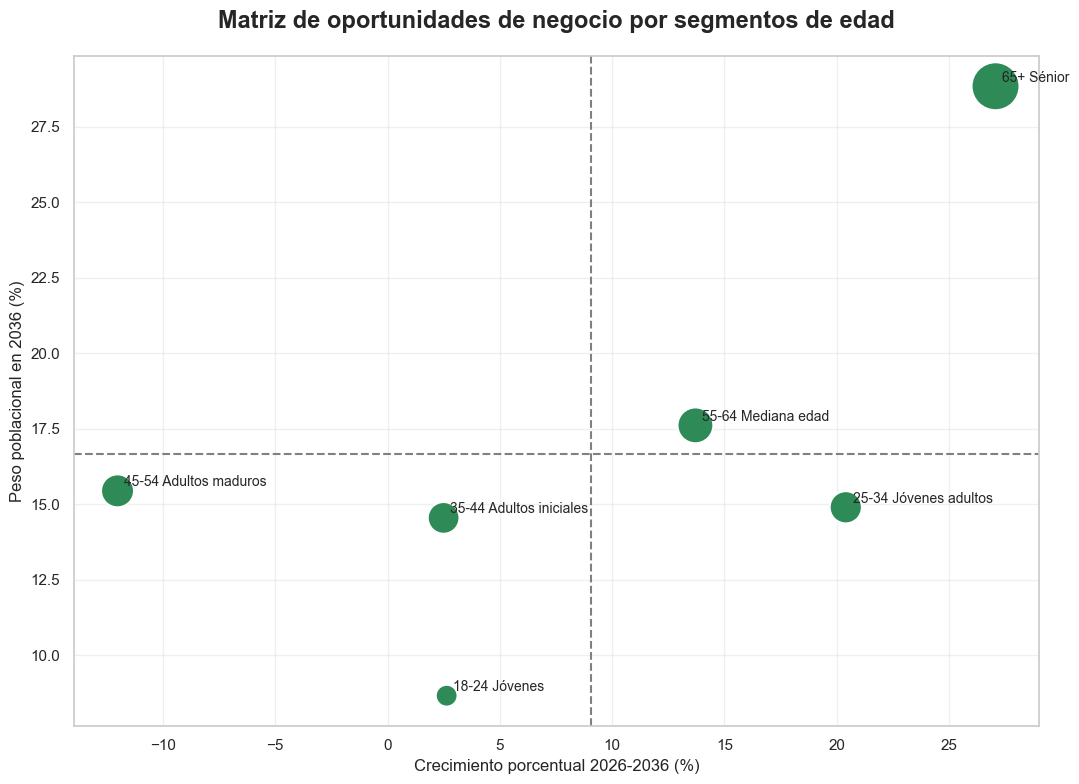

In [21]:
# =====================================================
# MATRIZ DE OPORTUNIDADES DE NEGOCIO
# =====================================================

sns.set_theme(style="whitegrid")

# Población por segmento y año
df_matriz = (
    df_segmentos_edad
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Tabla dinámica
pivot = (
    df_matriz
    .pivot(
        index="segmento_edad",
        columns="periodo",
        values="poblacion"
    )
)

# Crecimiento porcentual 2026-2036
crecimiento = (
    (pivot[2036] - pivot[2026])
    / pivot[2026]
    * 100
)

# Peso poblacional en 2036
peso = (
    pivot[2036]
    / pivot[2036].sum()
    * 100
)

# DataFrame resumen
df_oportunidades = (
    pd.DataFrame({
        "Segmento": crecimiento.index,
        "Crecimiento (%)": crecimiento.values,
        "Peso poblacional (%)": peso.values,
        "Población 2036": pivot[2036].values
    })
)

# =====================================================
# GRÁFICO
# =====================================================

plt.figure(figsize=(11,8))

sns.scatterplot(
    data=df_oportunidades,
    x="Crecimiento (%)",
    y="Peso poblacional (%)",
    size="Población 2036",
    sizes=(250,1200),
    legend=False,
    color="#2E8B57"
)

# Etiquetas
for _, fila in df_oportunidades.iterrows():
    plt.text(
        fila["Crecimiento (%)"]+0.3,
        fila["Peso poblacional (%)"]+0.15,
        fila["Segmento"],
        fontsize=10
    )

# Líneas de referencia (medias)
plt.axvline(
    df_oportunidades["Crecimiento (%)"].mean(),
    linestyle="--",
    color="gray"
)

plt.axhline(
    df_oportunidades["Peso poblacional (%)"].mean(),
    linestyle="--",
    color="gray"
)

plt.title(
    "Matriz de oportunidades de negocio por segmentos de edad",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Crecimiento porcentual 2026-2036 (%)",
    fontsize=12
)

plt.ylabel(
    "Peso poblacional en 2036 (%)",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Variación porcentual de la población por edad (2026-2036)

Además del análisis por segmentos de edad, resulta útil estudiar la evolución de cada edad individual para identificar con mayor precisión qué grupos de población experimentarán un mayor crecimiento o una mayor disminución durante el periodo analizado.

Para ello se calcula la variación porcentual entre la población proyectada en 2026 y la proyectada en 2036 para cada edad.

Este análisis permite detectar de forma detallada las edades que concentrarán el crecimiento demográfico y aquellas cuya población disminuirá, proporcionando una visión más granular que complementa la segmentación utilizada en el resto del estudio.

Desde el punto de vista de negocio, esta información ayuda a anticipar la evolución del mercado potencial y a identificar oportunidades para adaptar la oferta de productos financieros a grupos de edad específicos.

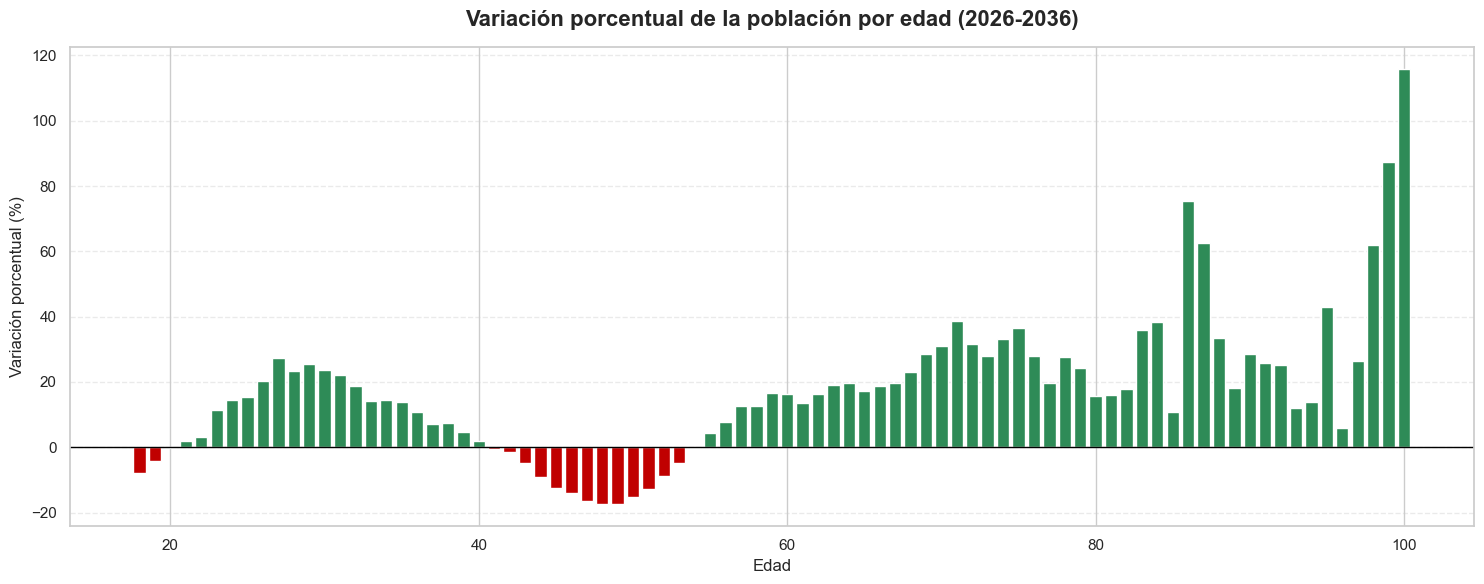

In [22]:
# =====================================================
# VARIACIÓN PORCENTUAL 2026-2036 POR EDAD
# =====================================================

# Población en 2026
pob_2026 = (
    df_poblacion_larga[df_poblacion_larga["periodo"] == 2026]
    .set_index("edad_num")["poblacion"]
)

# Población en 2036
pob_2036 = (
    df_poblacion_larga[df_poblacion_larga["periodo"] == 2036]
    .set_index("edad_num")["poblacion"]
)

# Calcular variación porcentual
variacion = (
    (pob_2036 - pob_2026)
    / pob_2026
    * 100
)

df_variacion = variacion.reset_index()
df_variacion.columns = ["edad", "variacion"]

# Colores según crecimiento o descenso
colores = [
    "#2E8B57" if x >= 0 else "#C00000"
    for x in df_variacion["variacion"]
]

# =====================================================
# GRÁFICO
# =====================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15,6))

plt.bar(
    df_variacion["edad"],
    df_variacion["variacion"],
    color=colores
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Variación porcentual de la población por edad (2026-2036)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Edad", fontsize=12)

plt.ylabel(
    "Variación porcentual (%)",
    fontsize=12
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## Análisis de tendencias mediante regresión lineal

Hasta este punto se ha analizado la evolución de la población mediante indicadores descriptivos como el crecimiento absoluto, el crecimiento porcentual y la tasa de crecimiento anual compuesta (CAGR). Sin embargo, estos indicadores no permiten determinar si la evolución observada responde a una tendencia consistente a lo largo del tiempo.

Para ello se aplica una **regresión lineal simple**, considerando:

- **Variable independiente (X):** año de la proyección.
- **Variable dependiente (Y):** población de cada segmento.

La regresión lineal ajusta una recta que representa la evolución media de la población en el tiempo y proporciona varios indicadores estadísticos:

- **Pendiente (Slope):** indica el cambio medio anual de la población. Una pendiente positiva implica crecimiento, mientras que una pendiente negativa indica una disminución del segmento.
- **Coeficiente de determinación (R²):** mide qué proporción de la variabilidad de la población es explicada por la tendencia temporal. Valores próximos a 1 indican un ajuste muy bueno.
- **Valor p (p-value):** permite evaluar si la tendencia observada es estadísticamente significativa. Se considera significativa cuando el valor p es inferior a 0,05.

Este análisis permite aportar evidencia estadística sobre la evolución de cada segmento poblacional y refuerza las conclusiones obtenidas mediante los indicadores descriptivos.

### Interpretación de los resultados

La pendiente indica el cambio medio anual de la población en cada segmento.

- Una **pendiente positiva** refleja un incremento sostenido del número de personas en ese segmento.
- Una **pendiente negativa** indica una disminución progresiva.

El coeficiente **R²** muestra la calidad del ajuste del modelo lineal. Valores próximos a 1 indican que la evolución del segmento sigue una tendencia temporal muy estable.

Por último, el **valor p** permite evaluar la significación estadística de la tendencia. Cuando **p < 0,05**, puede afirmarse que la evolución observada es estadísticamente significativa y difícilmente atribuible al azar.

Este análisis proporciona evidencia estadística que complementa los indicadores descriptivos, permitiendo fundamentar con mayor solidez las decisiones relacionadas con la redefinición de los segmentos de clientes.

from scipy.stats import linregress
import pandas as pd

# ==============================================
# REGRESIÓN LINEAL POR SEGMENTO DE EDAD
# ==============================================

resultados_regresion = []

for segmento in df_segmentos_edad["segmento_edad"].unique():

    datos = (
        df_segmentos_edad[
            df_segmentos_edad["segmento_edad"] == segmento
        ]
        .sort_values("periodo")
    )

    regresion = linregress(
        datos["periodo"],
        datos["poblacion"]
    )

    resultados_regresion.append({
        "Segmento": segmento,
        "Pendiente": regresion.slope,
        "Intercepto": regresion.intercept,
        "R²": regresion.rvalue**2,
        "p-value": regresion.pvalue
    })

df_regresion = pd.DataFrame(resultados_regresion)

# Redondear resultados
df_regresion["Pendiente"] = df_regresion["Pendiente"].round(0)
df_regresion["R²"] = df_regresion["R²"].round(4)
df_regresion["p-value"] = df_regresion["p-value"].round(6)

display(df_regresion)

# Clasificar la población en generaciones
## Segmentación por generaciones

Además de agrupar la población por intervalos de edad, resulta interesante analizar la evolución de las principales generaciones.

Esta clasificación agrupa a las personas según el periodo histórico en el que nacieron, ya que cada generación suele presentar patrones de consumo, uso de tecnología y comportamiento financiero diferentes.

En este análisis se consideran:

- Generación Z.
- Millennials.
- Generación X.
- Baby Boomers.

El objetivo es observar cómo evolucionará el peso de cada generación dentro de la población y anticipar posibles cambios en las necesidades del mercado.

Esta segmentación resulta especialmente útil para adaptar productos y estrategias comerciales dirigidas a perfiles generacionales concretos.

In [23]:
df_generaciones = df_poblacion_larga.copy()

condiciones = [
    df_generaciones["edad_num"].between(18,27),
    df_generaciones["edad_num"].between(28,43),
    df_generaciones["edad_num"].between(44,59),
    df_generaciones["edad_num"].between(60,79)
]

etiquetas = [
    "Generación Z",
    "Millennials",
    "Generación X",
    "Baby Boomers"
]

df_generaciones["generacion"] = np.select(
    condiciones,
    etiquetas,
    default="Otros"
)

df_generaciones = (
    df_generaciones
    .groupby(["periodo","generacion"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

display(df_generaciones)

,periodo,generacion,poblacion
0,2026,Baby Boomers,1.071484e+07
1,2026,Generación X,1.253690e+07
2,2026,Generación Z,5.546144e+06
3,2026,Millennials,9.805604e+06
4,2026,Otros,3.123589e+06
5,2027,Baby Boomers,1.097347e+07
6,2027,Generación X,1.258040e+07
7,2027,Generación Z,5.726592e+06
8,2027,Millennials,9.835257e+06
9,2027,Otros,3.198736e+06


## Índice de envejecimiento

El índice de envejecimiento mide la relación entre la población de mayor edad y la población joven.

Se calcula comparando el número de personas de 65 años o más con el número de personas menores de 25 años.

Este indicador permite evaluar el grado de envejecimiento de la población y analizar cómo evolucionará la estructura demográfica del país.

Un aumento del índice implica una mayor presencia de población sénior, lo que puede modificar la demanda de determinados productos y servicios financieros, especialmente aquellos relacionados con el ahorro, la jubilación o la planificación patrimonial.

In [24]:
df_indice = df_poblacion_larga.copy()

mayores = (
    df_indice[df_indice["edad_num"]>=65]
    .groupby("periodo")["poblacion"]
    .sum()
)

jovenes = (
    df_indice[df_indice["edad_num"]<=24]
    .groupby("periodo")["poblacion"]
    .sum()
)

indice_envejecimiento = (
    mayores
    / jovenes
    *100
)

display(indice_envejecimiento)

periodo
2026    269.150904
2027    267.205929
2028    267.329801
2029    269.786233
2030    274.475554
2031    280.219744
2032    288.926320
2033    298.141689
2034    309.321952
2035    320.468002
2036    333.226662
Name: poblacion, dtype: float64

## Índice de dependencia demográfica

El índice de dependencia relaciona la población considerada dependiente con la población en edad potencialmente activa.

En este análisis se considera población dependiente a:

- Personas menores de 25 años.
- Personas de 65 años o más.

La población activa corresponde al grupo comprendido entre los 25 y los 64 años.

Este indicador permite estimar cómo evolucionará la presión demográfica sobre la población en edad laboral y ayuda a comprender cambios futuros en el consumo, el ahorro y las necesidades financieras de los hogares.

In [25]:
dependientes = (
    df_indice[
        (df_indice["edad_num"]<=24) |
        (df_indice["edad_num"]>=65)
    ]
    .groupby("periodo")["poblacion"]
    .sum()
)

activos = (
    df_indice[
        df_indice["edad_num"].between(25,64)
    ]
    .groupby("periodo")["poblacion"]
    .sum()
)

indice_dependencia = (
    dependientes
    / activos
    *100
)

display(indice_dependencia)

periodo
2026    52.234550
2027    53.221688
2028    54.145127
2029    55.016129
2030    55.948008
2031    56.735884
2032    57.374608
2033    58.100609
2034    58.671972
2035    59.337821
2036    60.003515
Name: poblacion, dtype: float64

## Índices demográficos complementarios

Además del índice de envejecimiento y del índice de dependencia, se calculan tres indicadores que permiten describir la estructura de la población desde diferentes perspectivas.

Estos índices expresan el peso relativo de determinados grupos de edad sobre el total de la población proyectada, facilitando la interpretación de la evolución demográfica y apoyando la toma de decisiones estratégicas.

Los indicadores calculados son:

- **Índice de juventud:** porcentaje de población entre 18 y 34 años respecto al total de la población. Este indicador permite estimar el peso de los clientes potenciales más jóvenes.

- **Índice de población activa:** porcentaje de población entre 25 y 64 años respecto al total de la población. Representa la población en edad laboral y constituye el principal mercado potencial para productos financieros como hipotecas, inversión o seguros.

- **Índice sénior:** porcentaje de población de 65 años o más respecto al total de la población. Este indicador permite cuantificar el proceso de envejecimiento y anticipar una mayor demanda de productos relacionados con el ahorro, la jubilación y la planificación patrimonial.

Estos indicadores complementan el análisis realizado anteriormente y permiten evaluar cómo cambia la composición de la población a lo largo del horizonte temporal de las proyecciones.

In [26]:
# =====================================================
# ÍNDICES DEMOGRÁFICOS COMPLEMENTARIOS
# =====================================================

# Población total por año
total_poblacion = (
    df_poblacion_larga
    .groupby("periodo")["poblacion"]
    .sum()
)

# Índice de juventud (18-34 años)
indice_juventud = (
    df_poblacion_larga[
        df_poblacion_larga["edad_num"].between(18, 34)
    ]
    .groupby("periodo")["poblacion"]
    .sum()
    .div(total_poblacion)
    .mul(100)
)

# Índice de población activa (25-64 años)
indice_activa = (
    df_poblacion_larga[
        df_poblacion_larga["edad_num"].between(25, 64)
    ]
    .groupby("periodo")["poblacion"]
    .sum()
    .div(total_poblacion)
    .mul(100)
)

# Índice sénior (65 años o más)
indice_senior = (
    df_poblacion_larga[
        df_poblacion_larga["edad_num"] >= 65
    ]
    .groupby("periodo")["poblacion"]
    .sum()
    .div(total_poblacion)
    .mul(100)
)

# Crear tabla resumen
df_indices_demograficos = pd.DataFrame({
    "Índice de juventud (%)": indice_juventud,
    "Índice de población activa (%)": indice_activa,
    "Índice sénior (%)": indice_senior
})

# Redondear resultados
df_indices_demograficos = df_indices_demograficos.round(2)

display(df_indices_demograficos)

,Índice de juventud (%),Índice de población activa (%),Índice sénior (%)
periodo,,,
2026,22.93,65.69,25.02
2027,23.18,65.26,25.28
2028,23.35,64.87,25.56
2029,23.52,64.51,25.89
2030,23.66,64.12,26.30
2031,23.77,63.80,26.68
2032,23.80,63.54,27.08
2033,23.81,63.25,27.52
2034,23.79,63.02,27.94


# 1. Tendencia de crecimiento poblacional
Responde directamente a si el mercado potencial aumenta o disminuye.

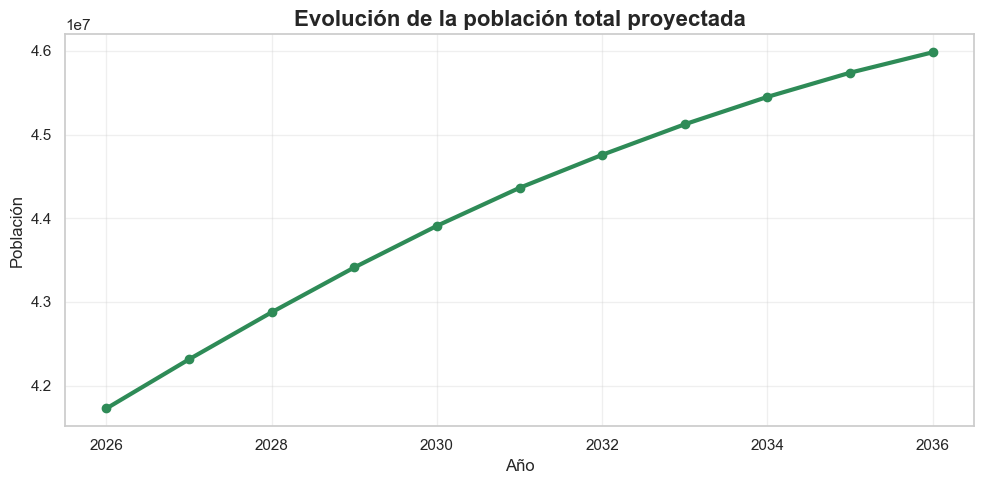

In [27]:
plt.figure(figsize=(10,5))

poblacion_total = (
    df_poblacion_larga
    .groupby("periodo")["poblacion"]
    .sum()
)

plt.plot(
    poblacion_total.index,
    poblacion_total.values,
    marker="o",
    linewidth=3,
    color="#2E8B57"
)

plt.title(
    "Evolución de la población total proyectada",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Año")
plt.ylabel("Población")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Tendencia del saldo vegetativo
El crecimiento no viene por nacimientos 

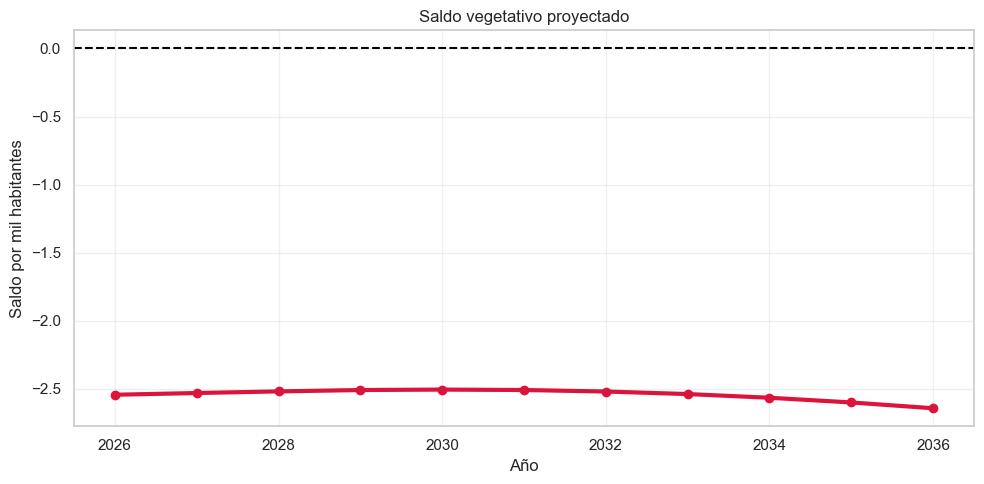

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    df_saldo_vegetativo["periodo"],
    df_saldo_vegetativo["saldo_vegetativo_por_mil"],
    marker="o",
    linewidth=3,
    color="crimson"
)

plt.axhline(0,color="black",linestyle="--")

plt.title("Saldo vegetativo proyectado")
plt.xlabel("Año")
plt.ylabel("Saldo por mil habitantes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

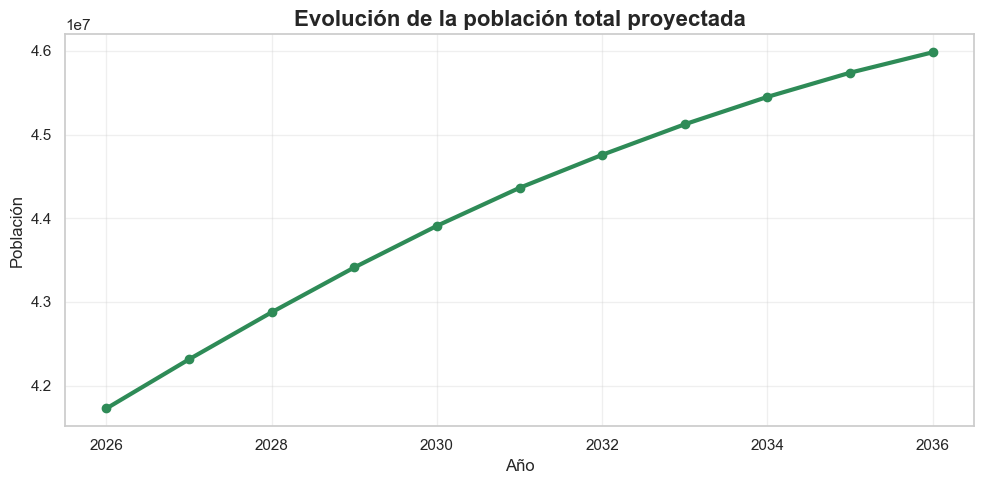

In [29]:
plt.figure(figsize=(10,5))

poblacion_total = (
    df_poblacion_larga
    .groupby("periodo")["poblacion"]
    .sum()
)

plt.plot(
    poblacion_total.index,
    poblacion_total.values,
    marker="o",
    linewidth=3,
    color="#2E8B57"
)

plt.title(
    "Evolución de la población total proyectada",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Año")
plt.ylabel("Población")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
df_migracion_neta.columns

Index(['periodo', 'tasa_migracion_neta'], dtype='str')

In [31]:
df_migracion_neta.head()

,periodo,tasa_migracion_neta
0,2026,12.348410
1,2027,11.973166
2,2028,11.325929
3,2029,10.531064
4,2030,9.683639


# 3. Tendencia del saldo migratorio
Nos explica de donde viene el crecimiento demografico

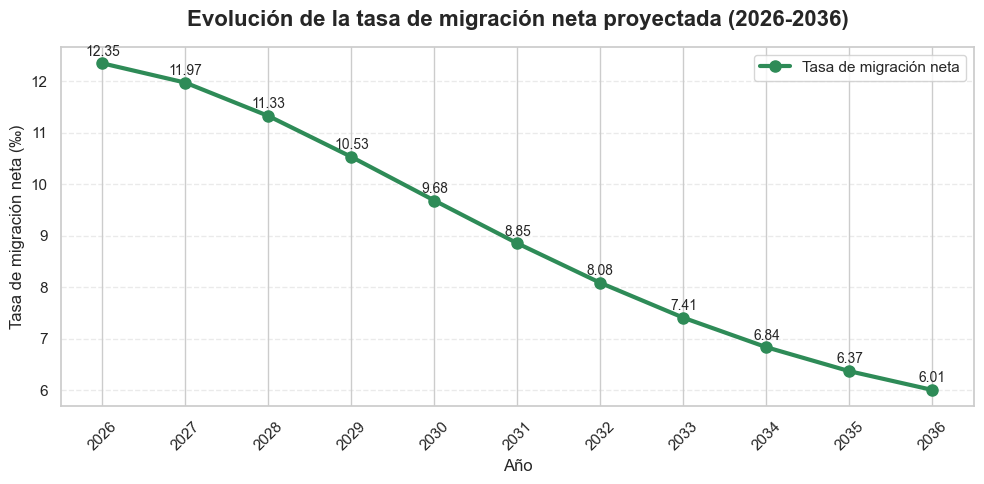

In [32]:
# =====================================================
# EVOLUCIÓN DE LA TASA DE MIGRACIÓN NETA PROYECTADA
# =====================================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

plt.plot(
    df_migracion_neta["periodo"],
    df_migracion_neta["tasa_migracion_neta"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#2E8B57",
    label="Tasa de migración neta"
)

# Etiquetas sobre cada punto
for x, y in zip(
    df_migracion_neta["periodo"],
    df_migracion_neta["tasa_migracion_neta"]
):
    plt.text(
        x,
        y + 0.15,
        f"{y:.2f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Evolución de la tasa de migración neta proyectada (2026-2036)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Año", fontsize=12)
plt.ylabel("Tasa de migración neta (‰)", fontsize=12)

plt.xticks(df_migracion_neta["periodo"], rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()

plt.show()

Gráfico conjunto (las tres tendencias)

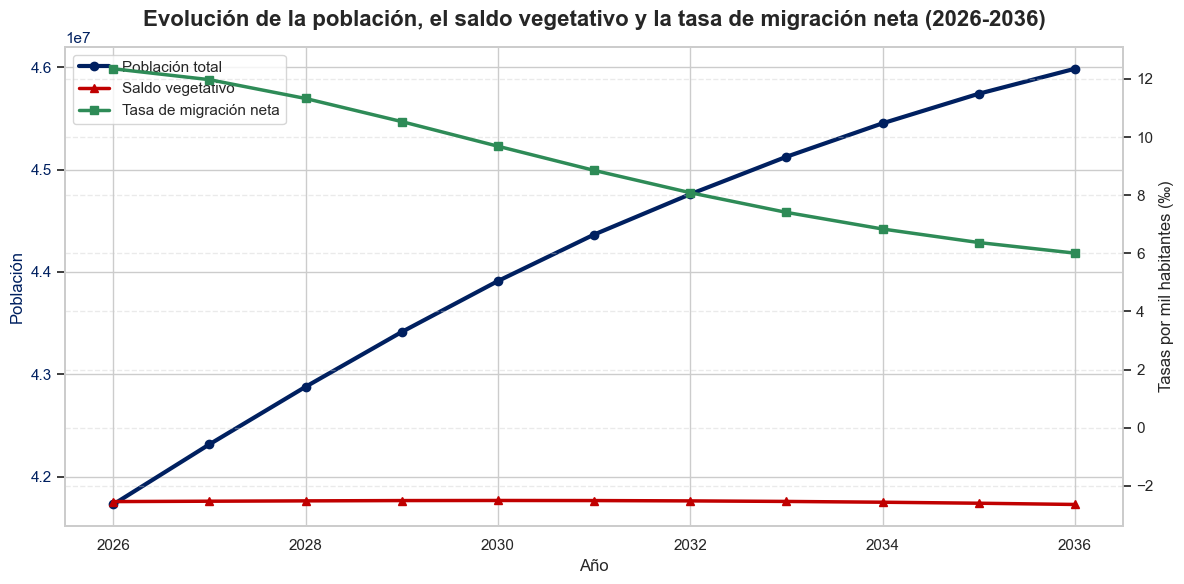

In [33]:
# =====================================================
# EVOLUCIÓN DE LA POBLACIÓN, SALDO VEGETATIVO
# Y TASA DE MIGRACIÓN NETA
# =====================================================

sns.set_theme(style="whitegrid")

# Población total por año
poblacion_total = (
    df_poblacion_larga
    .groupby("periodo")["poblacion"]
    .sum()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# =====================================================
# EJE IZQUIERDO: POBLACIÓN
# =====================================================

ax1.plot(
    poblacion_total.index,
    poblacion_total.values,
    color="#002060",
    linewidth=3,
    marker="o",
    label="Población total"
)

ax1.set_xlabel("Año", fontsize=12)

ax1.set_ylabel(
    "Población",
    fontsize=12,
    color="#002060"
)

ax1.tick_params(axis="y", labelcolor="#002060")

# =====================================================
# EJE DERECHO: INDICADORES DEMOGRÁFICOS
# =====================================================

ax2 = ax1.twinx()

# Saldo vegetativo
ax2.plot(
    df_saldo_vegetativo["periodo"],
    df_saldo_vegetativo["saldo_vegetativo_por_mil"],
    color="#C00000",
    linewidth=2.5,
    marker="^",
    label="Saldo vegetativo"
)

# Tasa de migración neta
ax2.plot(
    df_migracion_neta["periodo"],
    df_migracion_neta["tasa_migracion_neta"],
    color="#2E8B57",
    linewidth=2.5,
    marker="s",
    label="Tasa de migración neta"
)

ax2.set_ylabel(
    "Tasas por mil habitantes (‰)",
    fontsize=12
)

# =====================================================
# LEYENDA
# =====================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    fontsize=11
)

# =====================================================
# TÍTULO
# =====================================================

plt.title(
    "Evolución de la población, el saldo vegetativo y la tasa de migración neta (2026-2036)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.tight_layout()

plt.show()

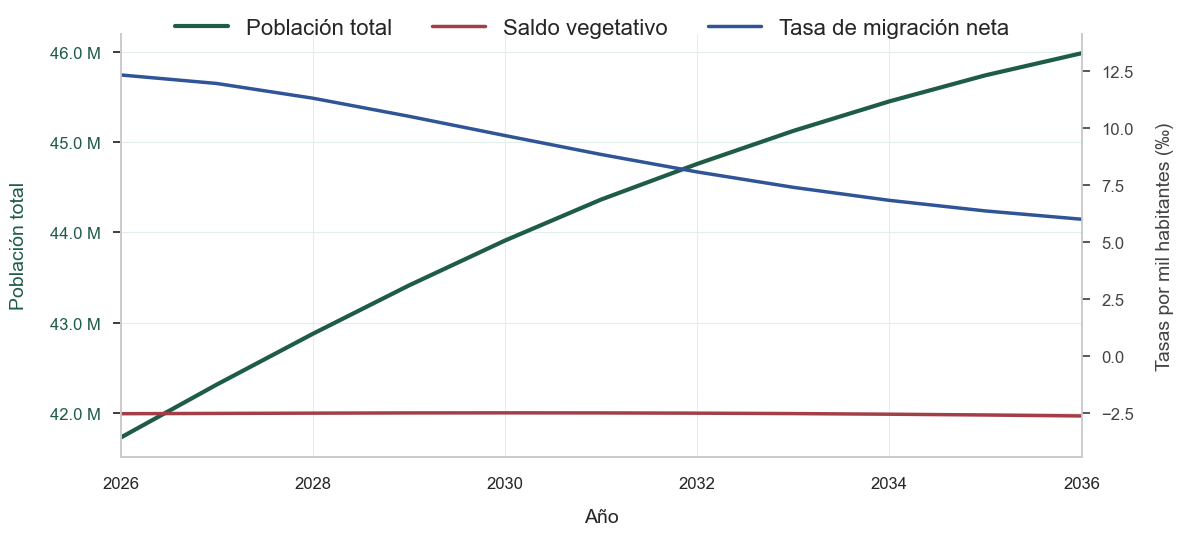

In [103]:
# =====================================================
# EVOLUCIÓN DE LA POBLACIÓN, SALDO VEGETATIVO
# Y TASA DE MIGRACIÓN NETA
# =====================================================

import matplotlib.ticker as mticker

sns.set_theme(style="white")

# Colores
color_poblacion = "#1F5C45"   # verde empresa
color_migracion = "#2F5597"   # azul
color_saldo = "#A23E48"       # granate suave
color_grid_y = "#DDEFE6"
color_grid_x = "#EAF5EF"

# Población total por año
poblacion_total = (
    df_poblacion_larga
    .groupby("periodo")["poblacion"]
    .sum()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# =====================================================
# EJE IZQUIERDO: POBLACIÓN
# =====================================================

ax1.plot(
    poblacion_total.index,
    poblacion_total.values,
    color=color_poblacion,
    linewidth=3,
    label="Población total"
)

ax1.set_xlabel("Año", fontsize=14, labelpad=12)
ax1.set_ylabel("Población total", fontsize=14, color=color_poblacion, labelpad=16)
ax1.tick_params(axis="y", labelcolor=color_poblacion, labelsize=12, pad=8)
ax1.tick_params(axis="x", labelsize=12, pad=8)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f} M")
)

# Eje X cada 2 años
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

# =====================================================
# EJE DERECHO: INDICADORES DEMOGRÁFICOS
# =====================================================

ax2 = ax1.twinx()

ax2.plot(
    df_saldo_vegetativo["periodo"],
    df_saldo_vegetativo["saldo_vegetativo_por_mil"],
    color=color_saldo,
    linewidth=2.5,
    label="Saldo vegetativo"
)

ax2.plot(
    df_migracion_neta["periodo"],
    df_migracion_neta["tasa_migracion_neta"],
    color=color_migracion,
    linewidth=2.5,
    label="Tasa de migración neta"
)

ax2.set_ylabel("Tasas por mil habitantes (‰)", fontsize=14, color="#444444", labelpad=16)
ax2.tick_params(axis="y", colors="#444444", labelsize=12, pad=8)

# Margen para que las tasas no queden pegadas
y2_min = min(
    df_saldo_vegetativo["saldo_vegetativo_por_mil"].min(),
    df_migracion_neta["tasa_migracion_neta"].min()
)

y2_max = max(
    df_saldo_vegetativo["saldo_vegetativo_por_mil"].max(),
    df_migracion_neta["tasa_migracion_neta"].max()
)

margen_y2 = (y2_max - y2_min) * 0.12
ax2.set_ylim(y2_min - margen_y2, y2_max + margen_y2)

# =====================================================
# GRID
# =====================================================

ax1.set_axisbelow(True)

ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

ax1.grid(
    axis="both",
    which="major",
    color="#DDEFE6",
    linewidth=0.8,
    alpha=0.9
)

# =====================================================
# LEYENDA FUERA DEL GRÁFICO
# =====================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=3,
    frameon=False,
    fontsize=16,
    handlelength=2.4,
    columnspacing=1.8
)

# =====================================================
# TÍTULO Y ESTÉTICA
# =====================================================
"""
fig.suptitle(
    "Evolución de la población, el saldo vegetativo y la tasa de migración neta (2026-2036)",
    fontsize=15,
    fontweight="bold",
    y=0.98
)
"""
ax1.set_xlim(
    poblacion_total.index.min(),
    poblacion_total.index.max()
)

# Bordes suaves
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

for ax in [ax1, ax2]:
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["right"].set_color("#CCCCCC")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

# Pirámide poblacional 2026

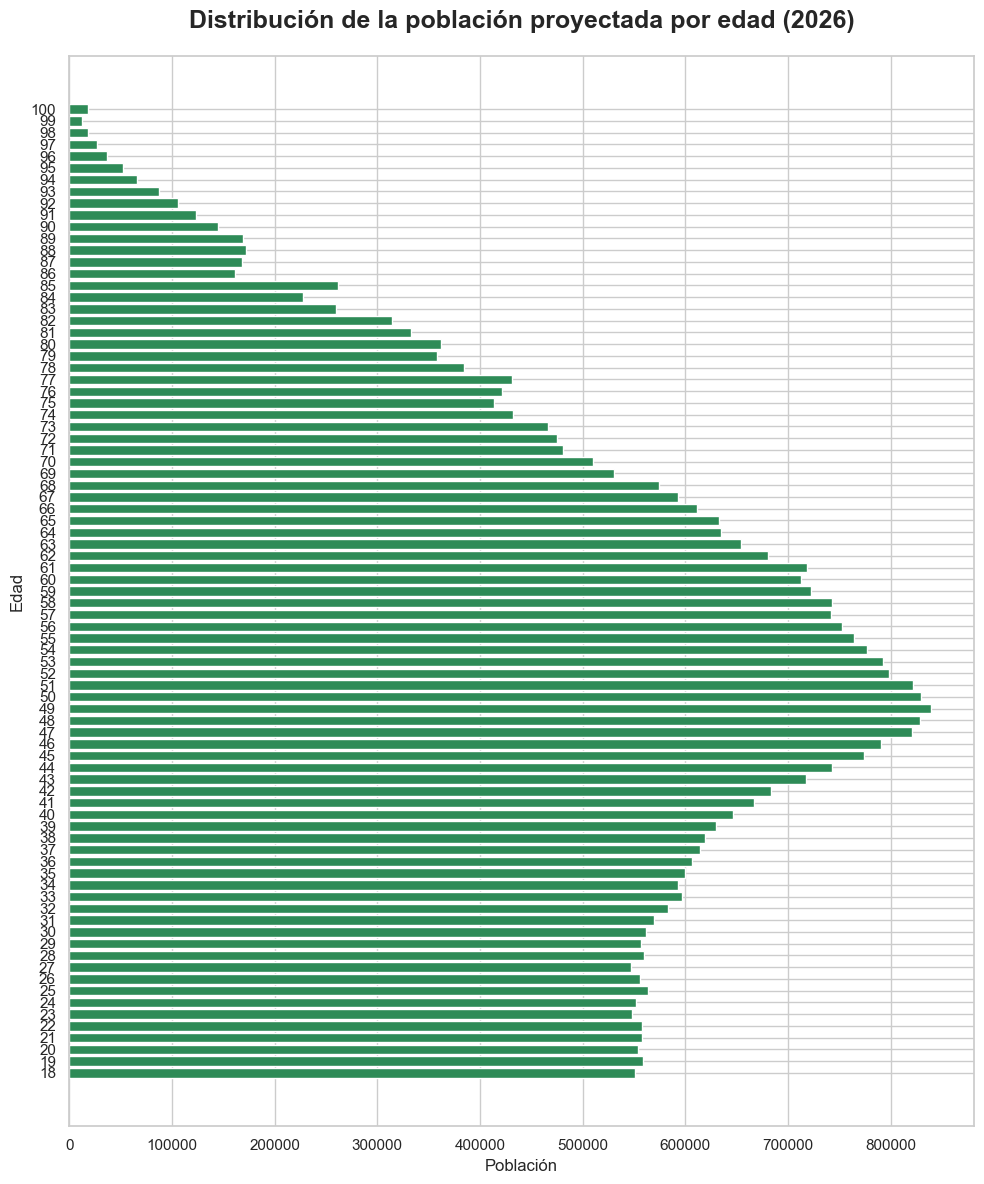

In [35]:
# =====================================================
# DISTRIBUCIÓN DE LA POBLACIÓN POR EDAD (2026)
# =====================================================

# Datos del año 2026
p2026 = (
    df_poblacion_larga[df_poblacion_larga["periodo"] == 2026]
    .sort_values("edad_num")
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 12))

plt.barh(
    p2026["edad_num"].astype(str),
    p2026["poblacion"],
    color="#2E8B57"  # Verde Sea Green
)

plt.title(
    "Distribución de la población proyectada por edad (2026)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Población")
plt.ylabel("Edad")

plt.tight_layout()
plt.show()

Incremento por edades (2026 vs 2036)

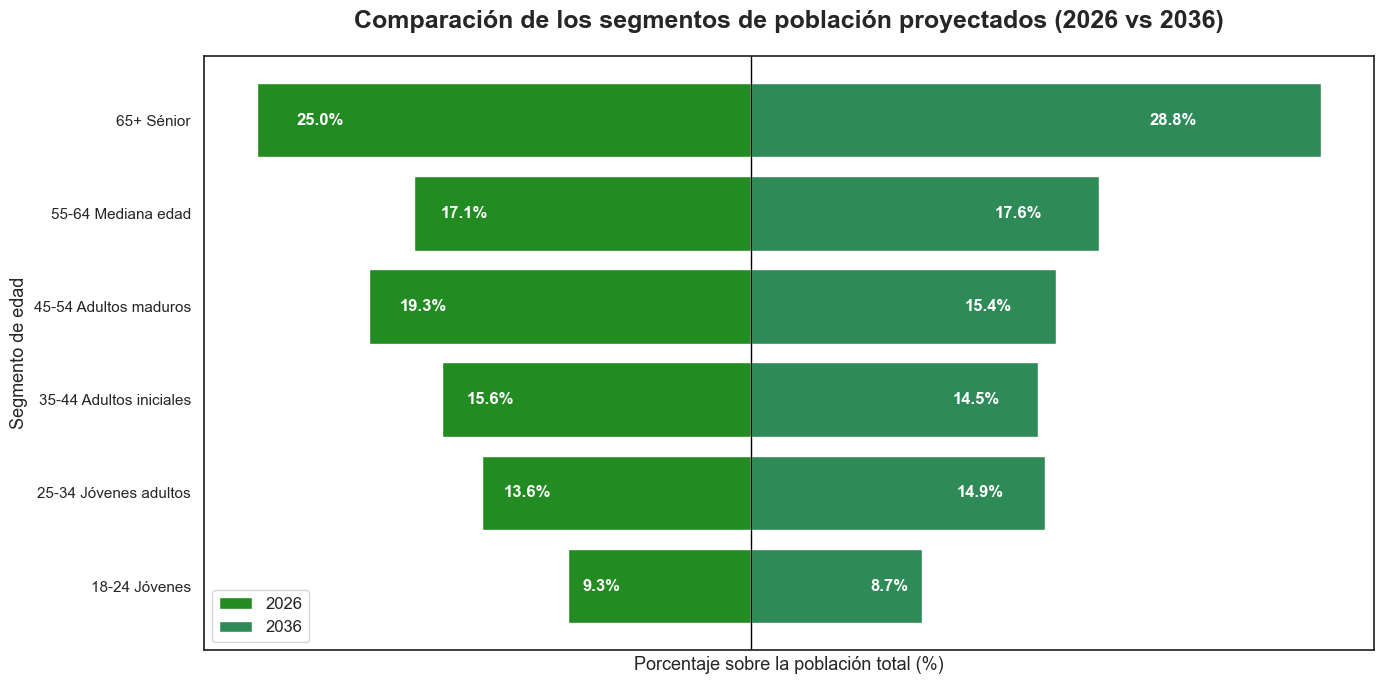

In [36]:
# =====================================================
# GRÁFICO TORNADO
# Comparación de los segmentos de población proyectados
# (2026 vs 2036)
# =====================================================

# Agrupar población por año y segmento
df_pyr = (
    df_segmentos
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Calcular porcentaje sobre el total de cada año
df_pyr["total"] = (
    df_pyr
    .groupby("periodo")["poblacion"]
    .transform("sum")
)

df_pyr["porcentaje"] = (
    df_pyr["poblacion"]
    / df_pyr["total"]
    * 100
)

# Crear tabla para el gráfico
tabla = (
    df_pyr
    .pivot(
        index="segmento_edad",
        columns="periodo",
        values="porcentaje"
    )
)

# Mantener el orden correcto de los segmentos
orden = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior"
]

tabla = tabla.loc[orden]

# Extraer datos
datos_2026 = tabla[2026].values
datos_2036 = tabla[2036].values

# Convertir 2026 a valores negativos para el gráfico tornado
datos_2026_neg = -datos_2026

segmentos = tabla.index.tolist()

# =====================================================
# GRÁFICO
# =====================================================

sns.set_theme(style="white")

plt.figure(figsize=(14, 7))

color_2026 = "#228B22"      # Azul corporativo
color_2036 = "#2E8B57"      # Verde Sea Green

# Barras
plt.barh(
    segmentos,
    datos_2026_neg,
    color=color_2026,
    label="2026"
)

plt.barh(
    segmentos,
    datos_2036,
    color=color_2036,
    label="2036"
)

# Etiquetas dentro de las barras (2026)
for y, v in enumerate(datos_2026_neg):
    plt.text(
        v * 0.92,
        y,
        f"{abs(v):.1f}%",
        va="center",
        ha="left",
        fontsize=12,
        color="white",
        fontweight="bold"
    )

# Etiquetas dentro de las barras (2036)
for y, v in enumerate(datos_2036):
    plt.text(
        v * 0.70,
        y,
        f"{v:.1f}%",
        va="center",
        ha="left",
        fontsize=12,
        color="white",
        fontweight="bold"
    )

# Línea central
plt.axvline(0, color="black", linewidth=1)

# Título
plt.title(
    "Comparación de los segmentos de población proyectados (2026 vs 2036)",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Etiquetas de los ejes
plt.xlabel("Porcentaje sobre la población total (%)", fontsize=13)
plt.ylabel("Segmento de edad", fontsize=13)

# Ocultar valores del eje X
plt.xticks([])

# Cuadrícula
plt.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

# Leyenda
plt.legend(fontsize=12)

# Ajuste final
plt.tight_layout()

plt.show()

Heatmap Edad × Año

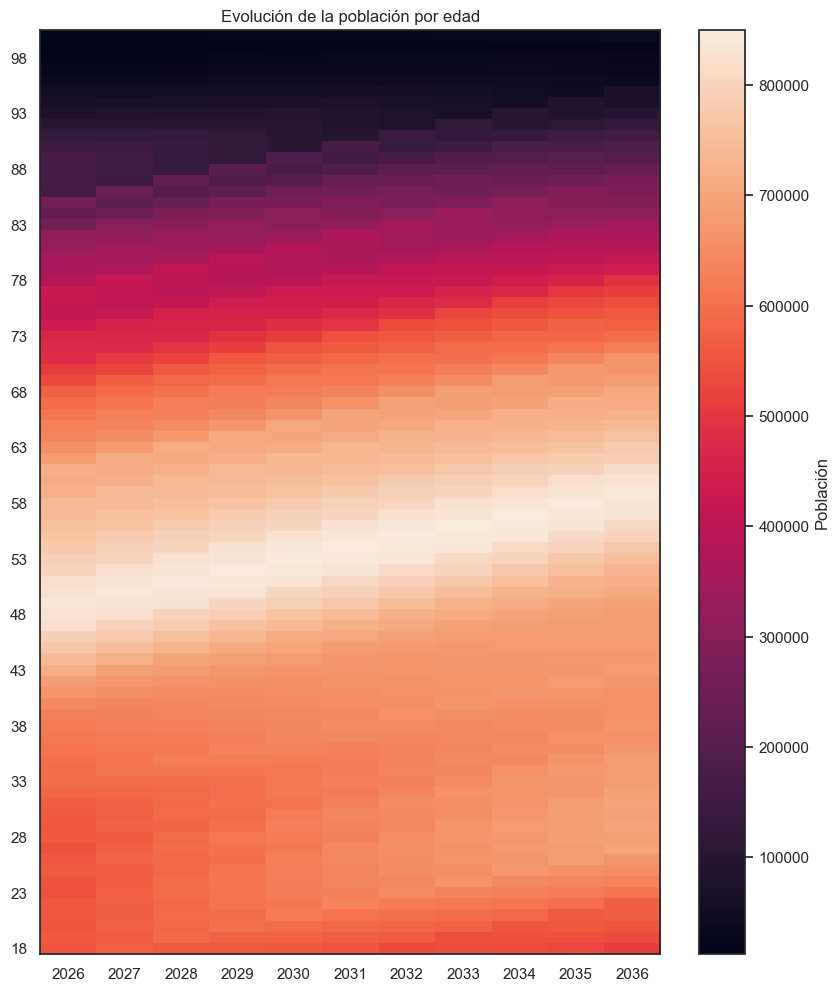

In [37]:
pivot = df_poblacion_larga.pivot_table(
    index="edad_num",
    columns="periodo",
    values="poblacion"
)

plt.figure(figsize=(10,12))

plt.imshow(
    pivot,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Población")

plt.yticks(range(0,len(pivot.index),5),pivot.index[::5])

plt.xticks(range(len(pivot.columns)),pivot.columns)

plt.title("Evolución de la población por edad")

plt.show()

## Evolución de la población por segmentos de edad

Con el objetivo de analizar cómo evolucionan los diferentes segmentos de población a lo largo del horizonte temporal de las proyecciones, se representa la evolución anual de cada grupo de edad mediante un gráfico de líneas.

Cada línea muestra la trayectoria de un segmento entre 2026 y 2036, permitiendo comparar visualmente su comportamiento y detectar qué grupos experimentan un crecimiento sostenido y cuáles presentan una disminución de población.

Este análisis complementa los indicadores de crecimiento absoluto, crecimiento porcentual y CAGR, proporcionando una visión dinámica de la evolución demográfica de cada segmento.

Desde una perspectiva de negocio, este gráfico facilita la identificación de los segmentos de clientes que previsiblemente ganarán relevancia en los próximos años y aquellos cuya importancia relativa disminuirá, aportando información útil para la redefinición de la segmentación y la adaptación de la oferta de productos financieros.

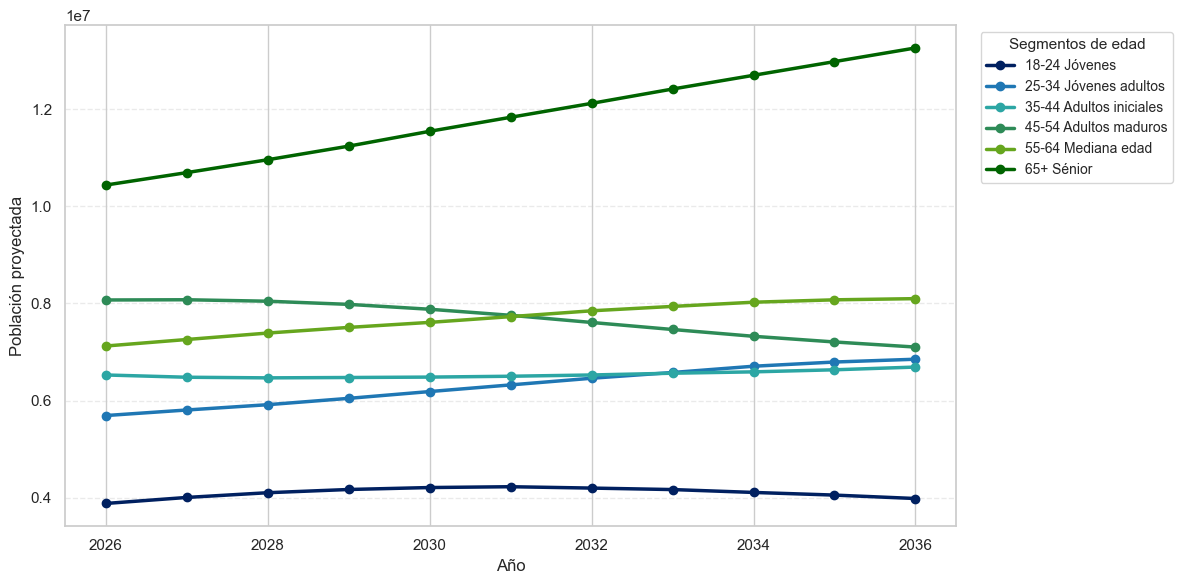

In [38]:
# =====================================================
# EVOLUCIÓN DE LA POBLACIÓN POR SEGMENTOS DE EDAD
# =====================================================

sns.set_theme(style="whitegrid")

# Agrupar población por año y segmento
segmentos = (
    df_segmentos_edad
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Crear tabla dinámica
pivot = (
    segmentos
    .pivot(
        index="periodo",
        columns="segmento_edad",
        values="poblacion"
    )
)

# Mantener el orden de los segmentos
orden = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior"
]

pivot = pivot[orden]

# Colores corporativos
colores = [
    "#002060",
    "#1F77B4",
    "#2CA6A4",
    "#2E8B57",
    "#66A61E",
    "#006400"
]

plt.figure(figsize=(12,6))

for color, columna in zip(colores, pivot.columns):
    plt.plot(
        pivot.index,
        pivot[columna],
        marker="o",
        linewidth=2.5,
        markersize=6,
        color=color,
        label=columna
    )
"""
plt.title(
    "Evolución de los segmentos de población proyectados (2026-2036)",
    fontsize=16,
    fontweight="bold",
    pad=15
)
"""
plt.xlabel("Año", fontsize=12)
plt.ylabel("Población proyectada", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Segmentos de edad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()

plt.show()

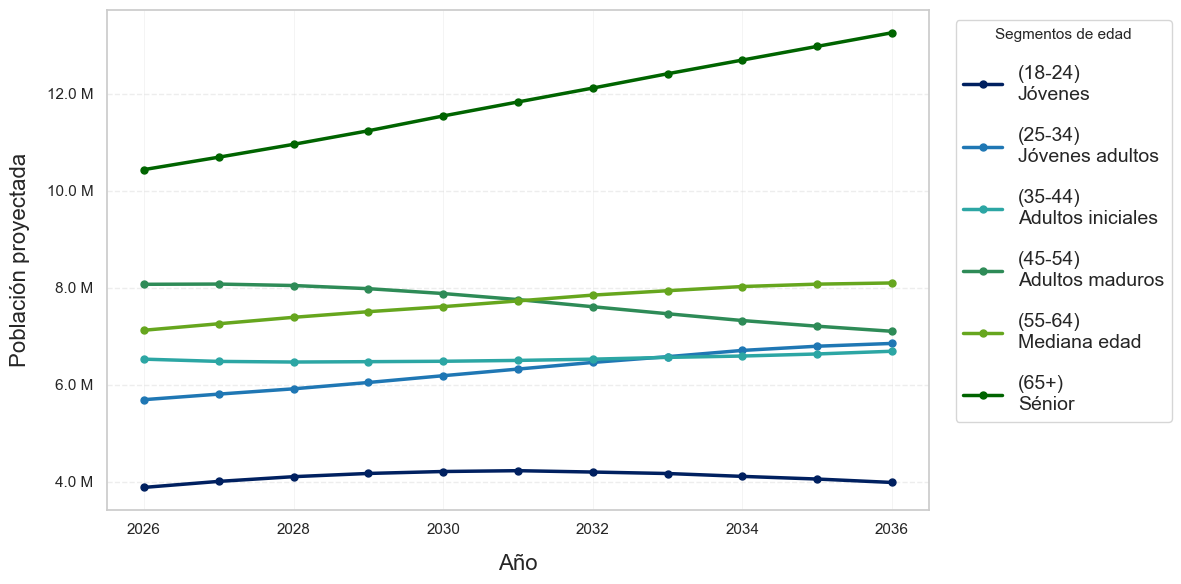

In [ ]:
# =====================================================
# EVOLUCIÓN DE LA POBLACIÓN POR SEGMENTOS DE EDAD
# =====================================================

import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid")

# Agrupar población por año y segmento
segmentos = (
    df_segmentos_edad
    .groupby(["periodo", "segmento_edad"], observed=True)["poblacion"]
    .sum()
    .reset_index()
)

# Crear tabla dinámica
pivot = (
    segmentos
    .pivot(
        index="periodo",
        columns="segmento_edad",
        values="poblacion"
    )
)

# Mantener el orden de los segmentos
orden = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior"
]

labels_leyenda = [
    "(18-24)\nJóvenes",
    "(25-34)\nJóvenes adultos",
    "(35-44)\nAdultos iniciales",
    "(45-54)\nAdultos maduros",
    "(55-64)\nMediana edad",
    "(65+)\nSénior"
]

pivot = pivot[orden]

# Colores más parecidos al original, pero algo más limpios
colores = [
    "#002060",
    "#1F77B4",
    "#2CA6A4",
    "#2E8B57",
    "#66A61E",
    "#006400"
]

fig, ax = plt.subplots(figsize=(12, 6))

for color, columna, label in zip(colores, pivot.columns, labels_leyenda):
    ax.plot(
        pivot.index,
        pivot[columna],
        marker="o",
        linewidth=2.5,
        markersize=5,
        color=color,
        label=label
    )

ax.set_xlabel("Año", fontsize=16, labelpad=12)  # labelpad dar espacio entre titulo de eje y números
ax.set_ylabel("Población proyectada", fontsize=16, labelpad=12)

# Mostrar eje Y en millones, sin 1e7
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f} M")
)

# Eje X cada 2 años
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# Grid horizontal suave
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Grid vertical finito cada 2 años
ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.6,
    alpha=0.25
)

ax.legend(
    title="Segmentos de edad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=14,
    title_fontsize=11,
    frameon=True,
    labelspacing=1.2  # far respirare la leyenda
)

plt.tight_layout()
plt.show()

# Bank Atlas

In [82]:
# cargar dataset bank atlas

df_bank = pd.read_csv(
    "../Data/2026-07-20_3_bank_dataset_transformed.csv"
)

display(df_bank.head())
print(df_bank.shape)

,id,age,job,marital,education,default,balance,housing,loan,contact,...,loan_score,vinculacion,productos_detalle,education_rank,education_label,job_profile,week_of_month,campaign_group,segment,segment_label
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,0,1,Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_0,Adultos consolidados
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,White Collar,1,0-3,Cluster_3,Jovenes en consolidación
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,0,2,Hipoteca + Depósito,2.0,Secondary,Blue Collar,1,0-3,Cluster_0,Adultos consolidados
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,0,1,Depósito,3.0,Tertiary,White Collar,1,0-3,Cluster_0,Adultos consolidados


(11150, 32)


In [ ]:
"""
def corregir_nombres_segmentos(df):
    df = df.copy()

    correcciones = {
        "Jovenes (18-24)": "(18-24) Jóvenes",
        "Jovenes adultos (25-34)": "(25-34) Jóvenes adultos",
        "Adultos iniciales(35-44)": "(35-44) Adultos iniciales",
        "Adultos maduros (45-54)": "(45-54) Adultos maduros",
        "Mediana edad (55-64)": "M(55-64) ediana edad",
        "Senior (65+)": "(65+) Sénior"
    }

    df["age_group"] = (
        df["age_group"]
        .astype("string")
        .replace(correcciones)
    )

    return df


df_bank = corregir_nombres_segmentos(df_bank)
"""

Revisar resultados bank atlas con nuevos grupos de edad

In [83]:
df_bank["age_group"].value_counts(
    sort=False,
    dropna=False
)

age_group
55-64 Mediana edad         1253
35-44 Adultos iniciales    3371
45-54 Adultos maduros      2202
25-34 Jóvenes adultos      3619
18-24 Jóvenes               281
65+ Sénior                  424
Name: count, dtype: int64

## Función reutilizable

In [84]:
def tabla_por_edad(df, variable):
    """
    Genera:
    1. Tabla de cantidades
    2. Tabla de porcentajes por grupo de edad
    """

    tabla_n = pd.crosstab(
        df["age_group"],
        df[variable]
    )

    tabla_pct = (
        pd.crosstab(
            df["age_group"],
            df[variable],
            normalize="index"
        )
        .mul(100)
        .round(1)
    )

    print(f"\n{variable.upper()} — CANTIDADES")
    display(tabla_n)

    print(f"\n{variable.upper()} — PORCENTAJES")
    display(tabla_pct)

    return tabla_n, tabla_pct

## Age group vs Deposit

In [85]:
df_bank["deposit"].value_counts(dropna=False)

deposit
0    5867
1    5283
Name: count, dtype: int64

In [86]:
# deposito

deposito_n, deposito_pct = tabla_por_edad(
    df_bank,
    "deposit"
)


DEPOSIT — CANTIDADES


deposit,0,1
age_group,,
18-24 Jóvenes,75,206
25-34 Jóvenes adultos,1848,1771
35-44 Adultos iniciales,1967,1404
45-54 Adultos maduros,1281,921
55-64 Mediana edad,612,641
65+ Sénior,84,340



DEPOSIT — PORCENTAJES


deposit,0,1
age_group,,
18-24 Jóvenes,26.7,73.3
25-34 Jóvenes adultos,51.1,48.9
35-44 Adultos iniciales,58.4,41.6
45-54 Adultos maduros,58.2,41.8
55-64 Mediana edad,48.8,51.2
65+ Sénior,19.8,80.2


- Sénior: mayor contratación del depósito, 80,2 %.Y el INE proyecta que será el segmento con mayor crecimiento.
- Jóvenes 18–24: contratación también muy elevada, 73,3 % (grupo pequeño: 281).
- Mediana edad 55–64: contratación del 51,2 %.
- Jóvenes adultos 25–34: 48,9 % (según INE crecimiento del 20,4%).
- Adultos iniciales y maduros 35–54: presentan las tasas más bajas, alrededor del 42 %.

Los segmentos sénior y joven presentan las tasas de contratación más elevadas (pero grupos más pequeños). El crecimiento proyectado de los segmentos sénior y 25–34 puede ampliar el mercado potencial del depósito.

## Age group vs Hipoteca

In [87]:
# hipoteca

hipoteca_n, hipoteca_pct = tabla_por_edad(
    df_bank,
    "housing"
)


HOUSING — CANTIDADES


housing,no,yes
age_group,,
18-24 Jóvenes,199,82
25-34 Jóvenes adultos,1741,1878
35-44 Adultos iniciales,1439,1932
45-54 Adultos maduros,1241,961
55-64 Mediana edad,846,407
65+ Sénior,405,19



HOUSING — PORCENTAJES


housing,no,yes
age_group,,
18-24 Jóvenes,70.8,29.2
25-34 Jóvenes adultos,48.1,51.9
35-44 Adultos iniciales,42.7,57.3
45-54 Adultos maduros,56.4,43.6
55-64 Mediana edad,67.5,32.5
65+ Sénior,95.5,4.5


- Adultos iniciales (35–44): presentan la mayor proporción de hipoteca, 57,3 %.
- Jóvenes adultos (25–34): segunda proporción más alta, 51,9 %.
- Jóvenes (18–24): 29,2 % porcentaje alto considerada la edad, grupo pequeño.
- Sénior (65+): solamente 4,5 % grupo muy pequeño.

Los jóvenes adultos combinan un crecimiento poblacional proyectado elevado (20,4 %) con una presencia importante de hipoteca en Banco Atlas (51,9 %), por lo que representan un segmento estratégico para productos de financiación de vivienda y ofertas vinculadas.

Aunque el segmento sénior será el de mayor crecimiento, su presencia de hipoteca es mínima, por lo que su oportunidad comercial probablemente se encuentre en productos diferentes, como depósitos, ahorro o inversión

## Age group vs préstamo

In [88]:
# prestamo

prestamo_n, prestamo_pct = tabla_por_edad(
    df_bank,
    "loan"
)


LOAN — CANTIDADES


loan,no,yes
age_group,,
18-24 Jóvenes,262,19
25-34 Jóvenes adultos,3127,492
35-44 Adultos iniciales,2933,438
45-54 Adultos maduros,1842,360
55-64 Mediana edad,1109,144
65+ Sénior,421,3



LOAN — PORCENTAJES


loan,no,yes
age_group,,
18-24 Jóvenes,93.2,6.8
25-34 Jóvenes adultos,86.4,13.6
35-44 Adultos iniciales,87.0,13.0
45-54 Adultos maduros,83.7,16.3
55-64 Mediana edad,88.5,11.5
65+ Sénior,99.3,0.7


- Adultos maduros (45–54): mayor presencia de préstamo personal, 16,3 %.
- Sénior (65+): prácticamente inexistente, 0,7 %.

El segmento 45–54 presenta actualmente la mayor utilización del préstamo personal, pero el INE proyecta una reducción de aproximadamente el 12 % de su población.

Los jóvenes adultos presentan una utilización intermedia del préstamo personal —13,6 %— y un fuerte crecimiento demográfico proyectado, por lo que podrían ganar importancia relativa dentro del mercado de crédito personal.

El fuerte crecimiento demográfico del segmento sénior no implica una oportunidad para todos los productos: su presencia de hipoteca y préstamo personal es muy reducida, mientras que destaca su contratación del depósito.

## Age group vs vinculación

In [89]:
# vinculación

vinculacion_n, vinculacion_pct = tabla_por_edad(
    df_bank,
    "vinculacion"
)


VINCULACION — CANTIDADES


vinculacion,0,1,2,3
age_group,,,,
18-24 Jóvenes,30,199,48,4
25-34 Jóvenes adultos,591,2017,909,102
35-44 Adultos iniciales,595,1861,832,83
45-54 Adultos maduros,525,1165,459,53
55-64 Mediana edad,296,745,189,23
65+ Sénior,82,322,20,0



VINCULACION — PORCENTAJES


vinculacion,0,1,2,3
age_group,,,,
18-24 Jóvenes,10.7,70.8,17.1,1.4
25-34 Jóvenes adultos,16.3,55.7,25.1,2.8
35-44 Adultos iniciales,17.7,55.2,24.7,2.5
45-54 Adultos maduros,23.8,52.9,20.8,2.4
55-64 Mediana edad,23.6,59.5,15.1,1.8
65+ Sénior,19.3,75.9,4.7,0.0


- Jóvenes adultos 25–34: Son el segmento con mayor vinculación multiproducto —27,9 %— y el INE proyecta un crecimiento demográfico del 20,4 %. Combinan, por tanto, crecimiento futuro y una vinculación financiera actualmente elevada.
- Sénior 65+: El 75,9 % tiene solamente uno de los tres productos y únicamente el 4,7 % es multiproducto. Teniendo en cuenta su elevada contratación del depósito y su reducida presencia de crédito, existe margen para ampliar su vinculación mediante productos adecuados al segmento (deposito).
- Jóvenes 18–24: El 70,8 % tiene un solo producto y el 10,7 % no tiene ninguno. Presentan potencial para desarrollar progresivamente la relación con el banco.
- Adultos maduros y mediana edad: Son los segmentos con mayor proporción sin ninguno de los tres productos analizados: 23,8 % y 23,6 %, respectivamente.

## Age group vs detalle productos

In [90]:
# todos los productos

productos_n, productos_pct = tabla_por_edad(
    df_bank,
    "productos_detalle"
)


PRODUCTOS_DETALLE — CANTIDADES


productos_detalle,Depósito,Hipoteca,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Ninguno,Préstamo,Préstamo + Depósito
age_group,,,,,,,,
18-24 Jóvenes,160,36,36,6,4,30,3,6
25-34 Jóvenes adultos,955,951,630,195,102,591,111,84
35-44 Adultos iniciales,685,1062,591,196,83,595,114,45
45-54 Adultos maduros,536,507,274,127,53,525,122,58
55-64 Mediana edad,475,217,121,46,23,296,53,22
65+ Sénior,320,2,17,0,0,82,0,3



PRODUCTOS_DETALLE — PORCENTAJES


productos_detalle,Depósito,Hipoteca,Hipoteca + Depósito,Hipoteca + Préstamo,Hipoteca + Préstamo + Depósito,Ninguno,Préstamo,Préstamo + Depósito
age_group,,,,,,,,
18-24 Jóvenes,56.9,12.8,12.8,2.1,1.4,10.7,1.1,2.1
25-34 Jóvenes adultos,26.4,26.3,17.4,5.4,2.8,16.3,3.1,2.3
35-44 Adultos iniciales,20.3,31.5,17.5,5.8,2.5,17.7,3.4,1.3
45-54 Adultos maduros,24.3,23.0,12.4,5.8,2.4,23.8,5.5,2.6
55-64 Mediana edad,37.9,17.3,9.7,3.7,1.8,23.6,4.2,1.8
65+ Sénior,75.5,0.5,4.0,0.0,0.0,19.3,0.0,0.7


- Jóvenes 18–24: segmento fuertemente concentrado en el depósito como único producto
- Jóvenes adultos 25–34: Es el segmento más diversificado: depósito e hipoteca tienen prácticamente el mismo peso y presenta la mayor vinculación multiproducto. Al crecer un 20,4 % según el INE, resulta especialmente relevante para ofertas combinadas de financiación y ahorro
- Adultos iniciales 35–44: segmento más orientado a la hipoteca
- Adultos maduros 45-54: No existe una combinación claramente dominante y tiene la mayor proporción sin ninguno de los tres productos
- - Mediana edad 55–64: El depósito gana importancia y disminuye la presencia de hipoteca. Como el INE proyecta un crecimiento del 13,7 %, puede ser relevante para ahorro y preparación de la jubilación
- Sénior 65+: segmento concentrado en depósito, muy pocos productos de crédito. Crecimiento poblacional, ofertas de ahorro?

## Age group vs balance

In [91]:
# balance

tabla_balance = (
    df_bank
    .groupby("age_group")
    .agg(
        clientes=("balance", "size"),
        balance_medio=("balance", "mean"),
        balance_mediano=("balance", "median")
    )
    .round(1)
)

display(tabla_balance)

,clientes,balance_medio,balance_mediano
age_group,,,
18-24 Jóvenes,281,1081.8,474.0
25-34 Jóvenes adultos,3619,1289.7,454.0
35-44 Adultos iniciales,3371,1419.7,527.0
45-54 Adultos maduros,2202,1580.2,582.5
55-64 Mediana edad,1253,2068.8,786.0
65+ Sénior,424,2888.6,1480.0


- Sénior: Es el segmento con mayor crecimiento proyectado, mayor contratación del depósito y mayor balance mediano (productos de ahorro e inversión adaptados)
- Mediana edad 55–64: Crecerá aproximadamente un 13,7 %, tiene un balance mediano de 786 € y una concentración creciente en depósitos (ahorro y planificación previa a la jubilación)
- Jóvenes adultos 25–34: Crecerán aproximadamente un 20,4 %. Presentan el balance mediano más bajo, 454 € pero también una elevada presencia de hipoteca y la mayor vinculación multiproducto (productos de financiación, gestión liquidez y construcción progresiva del ahorro)


## Tabla resumen

In [95]:
# =====================================================
# TABLA RESUMEN INE + BANCO ATLAS
# =====================================================

# Unificar cualquier variante anterior de los nombres
nombres_segmentos = {
    "18-24 Jóvenes": "(18-24) Jóvenes",
    "25-34 Jóvenes adultos": "(25-34) Jóvenes adultos",
    "35-44 Adultos iniciales": "(35-44) Adultos iniciales",
    "45-54 Adultos maduros": "(45-54) Adultos maduros",
    "55-64 Mediana edad": "(55-64) Mediana edad",
    "65+ Sénior": "(65+) Sénior"}

    # Nombres sin corregir de Banco Atlas (si encara els necessites)
    #"Jovenes (18-24)": "Jóvenes (18-24)",
    #"Jovenes adultos (25-34)": "Jóvenes adultos (25-34)",
    #"Adultos iniciales(35-44)": "Adultos iniciales (35-44)",
    #"Senior (65+)": "Sénior (65+)"}


orden_segmentos = [
    "(18-24) Jóvenes",
    "(25-34) Jóvenes adultos",
    "(35-44) Adultos iniciales",
    "(45-54) Adultos maduros",
    "(55-64) Mediana edad",
    "(65+) Sénior"
]

tabla_resumen = pd.concat(
    [
        df_crecimiento["crecimiento_%"]
        .rename(index=nombres_segmentos)
        .rename("Crecimiento INE (%)"),

        deposito_pct[1]
        .rename(index=nombres_segmentos)
        .rename("Depósito (%)"),

        hipoteca_pct["yes"]
        .rename(index=nombres_segmentos)
        .rename("Hipoteca (%)"),

        prestamo_pct["yes"]
        .rename(index=nombres_segmentos)
        .rename("Préstamo (%)"),

        (
            vinculacion_pct[2]
            + vinculacion_pct[3]
        )
        .rename(index=nombres_segmentos)
        .rename("Multiproducto (%)"),

        tabla_balance["balance_mediano"]
        .rename(index=nombres_segmentos)
        .rename("Balance mediano (€)")
    ],
    axis=1
)

tabla_resumen = (
    tabla_resumen
    .reindex(orden_segmentos)
    .round(1)
)

# Completar el crecimiento INE siguiendo el mismo orden
tabla_resumen["Crecimiento INE (%)"] = (
    df_crecimiento["crecimiento_%"].round(1).to_numpy()
)

display(tabla_resumen)

,Crecimiento INE (%),Depósito (%),Hipoteca (%),Préstamo (%),Multiproducto (%),Balance mediano (€)
(18-24) Jóvenes,2.6,73.3,29.2,6.8,18.5,474.0
(25-34) Jóvenes adultos,20.4,48.9,51.9,13.6,27.9,454.0
(35-44) Adultos iniciales,2.5,41.6,57.3,13.0,27.2,527.0
(45-54) Adultos maduros,-12.0,41.8,43.6,16.3,23.2,582.5
(55-64) Mediana edad,13.7,51.2,32.5,11.5,16.9,786.0
(65+) Sénior,27.1,80.2,4.5,0.7,4.7,1480.0


In [96]:
for nombre, serie in [
    ("crecimiento", df_crecimiento["crecimiento_%"]),
    ("deposito", deposito_pct[1]),
    ("hipoteca", hipoteca_pct["yes"]),
    ("prestamo", prestamo_pct["yes"]),
    ("vinculacion", vinculacion_pct[2] + vinculacion_pct[3]),
    ("balance", tabla_balance["balance_mediano"]),
]:
    print(nombre, "->", list(serie.index))


crecimiento -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']
deposito -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']
hipoteca -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']
prestamo -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']
vinculacion -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']
balance -> ['18-24 Jóvenes', '25-34 Jóvenes adultos', '35-44 Adultos iniciales', '45-54 Adultos maduros', '55-64 Mediana edad', '65+ Sénior']


## Insights

- Sénior (65+): mayor crecimiento proyectado, +27,1 %; mayor contratación del depósito, 80,2 %; y mayor balance mediano, 1.480 €. Sin embargo, solo el 4,7 % es multiproducto y casi no tiene crédito. Es el principal segmento para ahorro, inversión y ampliación de la vinculación con productos adecuados a su etapa vital.
- Jóvenes adultos (25–34): crecerán un 20,4 %, presentan una elevada presencia de hipoteca, 51,9 %, y el mayor porcentaje multiproducto, 27,9 %. Aunque tienen el balance mediano más bajo, 454 €, constituyen un segmento prioritario para financiación de vivienda, paquetes Hipoteca + Depósito y construcción progresiva del ahorro.
- Mediana edad (55–64): crecerá un 13,7 %, presenta un balance mediano relativamente elevado, 786 €, y una contratación del depósito del 51,2 %. Puede ser relevante para productos de ahorro y preparación de la jubilación.
- Jóvenes 18–24: contratación del depósito muy elevada, 73,3 %, pero poco crecimiento demográfico y una muestra pequeña de 281 clientes. Interesan para onboarding y vinculación futura, no por expansión poblacional inmediata.
- Adultos iniciales 35–44: poco crecimiento, pero máxima presencia de hipoteca, 57,3 %, y elevada vinculación multiproducto, 27,2 %. Son importantes para fidelización y cross-selling.
- Adultos maduros 45–54: único segmento en descenso, −12 %, y mayor presencia de préstamo personal, 16,3 %. Conviene mantener y fidelizar, pero no parece el principal foco de expansión.

No es necesario sustituir los segmentos actuales, pero sí cambiar su prioridad y adaptar la oferta: ahorro e inversión para sénior y mediana edad; financiación y productos combinados para jóvenes adultos; y fidelización/cross-selling para los segmentos adultos ya consolidados.

## Test

In [78]:
def test_chi_cuadrado(df, variable):
    tabla = pd.crosstab(
        df["age_group"],
        df[variable]
    )

    chi2, p_value, gl, esperadas = chi2_contingency(tabla)

    return {
        "Variable": variable,
        "Chi-cuadrado": round(chi2, 2),
        "Grados de libertad": gl,
        "p-value": p_value
    }

resultados_chi = pd.DataFrame([
    test_chi_cuadrado(df_bank, "deposit"),
    test_chi_cuadrado(df_bank, "housing"),
    test_chi_cuadrado(df_bank, "loan"),
    test_chi_cuadrado(df_bank, "vinculacion")
])

display(resultados_chi)

,Variable,Chi-cuadrado,Grados de libertad,p-value
0,deposit,341.18,5,1.387223e-71
1,housing,637.18,5,1.864936e-135
2,loan,91.42,5,3.381786e-18
3,vinculacion,246.98,15,5.192380e-44


El test de chi-cuadrado confirma una asociación estadísticamente significativa entre el segmento de edad y la contratación de depósitos, hipotecas y préstamos, así como con el nivel de vinculación (p < 0,001 en todos los casos).
Por tanto, las diferencias observadas entre los grupos de edad no parecen responder al azar, aunque el resultado indica asociación y no causalidad.

## Comparación gráfica proyección / vinculación actual

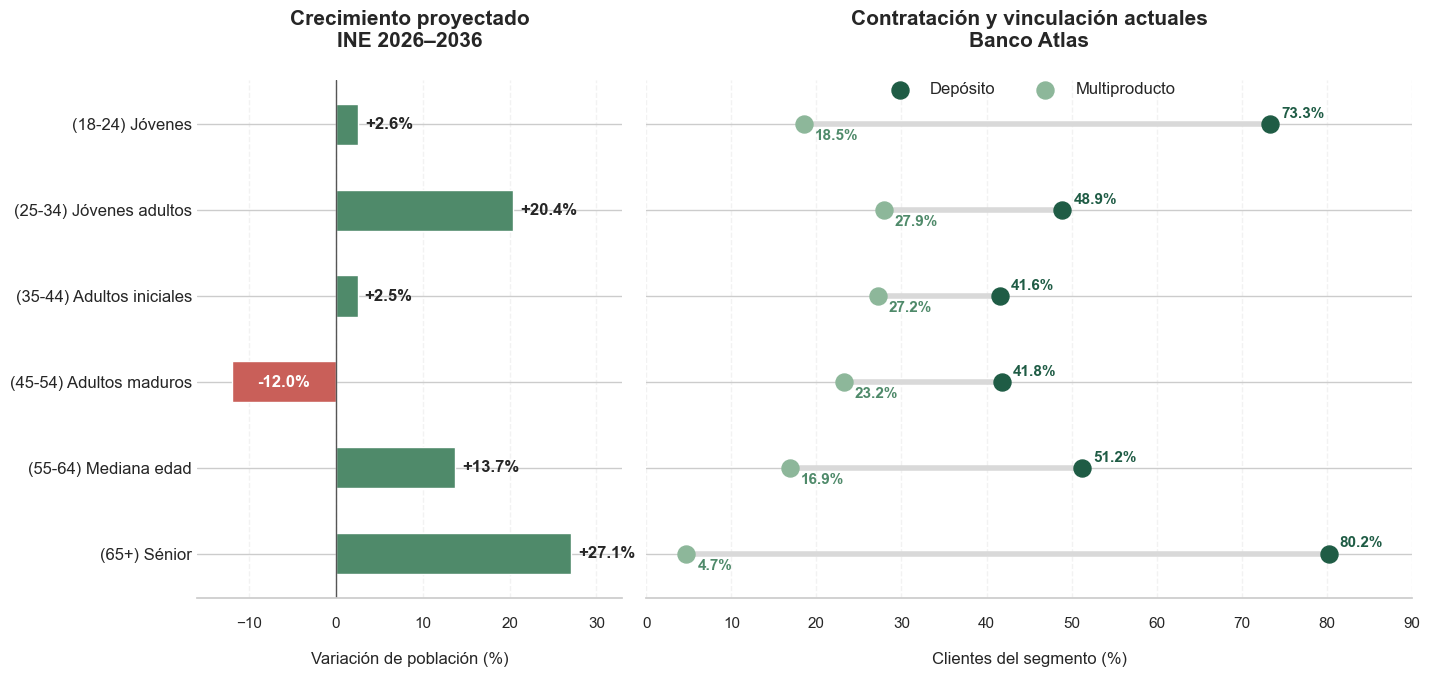

In [97]:
segmentos = tabla_resumen.index.tolist()
crecimiento = tabla_resumen["Crecimiento INE (%)"].to_numpy()
deposito = tabla_resumen["Depósito (%)"].to_numpy()
multiproducto = tabla_resumen["Multiproducto (%)"].to_numpy()

y = np.arange(len(segmentos))

verde_oscuro = "#1F5C45"
verde_medio = "#4F8A6A"
verde_claro = "#8DB79A"
rojo = "#C95F59"
gris = "#D9D9D9"

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(15, 7.5),
    sharey=True,
    gridspec_kw={
        "width_ratios": [1, 1.8],
        "wspace": 0.04
    }
)

# ==========================================================
# IZQUIERDA: CRECIMIENTO INE
# ==========================================================

colores_crecimiento = [
    verde_medio if valor >= 0 else rojo
    for valor in crecimiento
]

ax1.barh(
    y,
    crecimiento,
    color=colores_crecimiento,
    height=0.48
)

ax1.axvline(
    0,
    color="#555555",
    linewidth=1
)

for i, valor in enumerate(crecimiento):

    if valor >= 0:
        ax1.text(
            valor + 0.8,
            i,
            f"+{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold"
        )

    else:
        # Valor negativo dentro de la barra
        ax1.text(
            valor / 2,
            i,
            f"{valor:.1f}%",
            va="center",
            ha="center",
            fontsize=12,
            fontweight="bold",
            color="white"
        )

ax1.set_yticks(y)
ax1.set_yticklabels(
    segmentos,
    fontsize=12
)

ax1.set_xlim(-16, 33)

ax1.set_xlabel(
    "Variación de población (%)",
    fontsize=12,
    labelpad=15
)

ax1.set_title(
    "Crecimiento proyectado\nINE 2026–2036",
    fontsize=15,
    fontweight="bold",
    pad=24
)

ax1.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax1.set_axisbelow(True)


# ==========================================================
# DERECHA: DEPÓSITO Y MULTIPRODUCTO
# ==========================================================

for i in range(len(segmentos)):
    ax2.plot(
        [multiproducto[i], deposito[i]],
        [i, i],
        color=gris,
        linewidth=4,
        zorder=1
    )

ax2.scatter(
    deposito,
    y,
    s=150,
    color=verde_oscuro,
    label="Depósito",
    zorder=3
)

ax2.scatter(
    multiproducto,
    y,
    s=150,
    color=verde_claro,
    label="Multiproducto",
    zorder=3
)

for i, valor in enumerate(deposito):
    ax2.text(
        valor + 1.3,
        i - 0.12,
        f"{valor:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=verde_oscuro
    )

for i, valor in enumerate(multiproducto):
    ax2.text(
        valor + 1.3,
        i + 0.14,
        f"{valor:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=verde_medio
    )

ax2.set_xlim(0, 90)

ax2.set_xlabel(
    "Clientes del segmento (%)",
    fontsize=12,
    labelpad=15
)

ax2.set_title(
    "Contratación y vinculación actuales\nBanco Atlas",
    fontsize=15,
    fontweight="bold",
    pad=24
)

ax2.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.025),
    ncol=2,
    frameon=False,
    fontsize=12
)

ax2.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax2.set_axisbelow(True)

ax1.invert_yaxis()

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="y",
        length=0
    )

    ax.tick_params(
        axis="x",
        labelsize=11,
        pad=8
    )

# Más aire arriba y abajo
plt.subplots_adjust(
    top=0.84,
    bottom=0.15,
    left=0.17,
    right=0.98
)

plt.show()

## Gráfico productos financieros (opción)

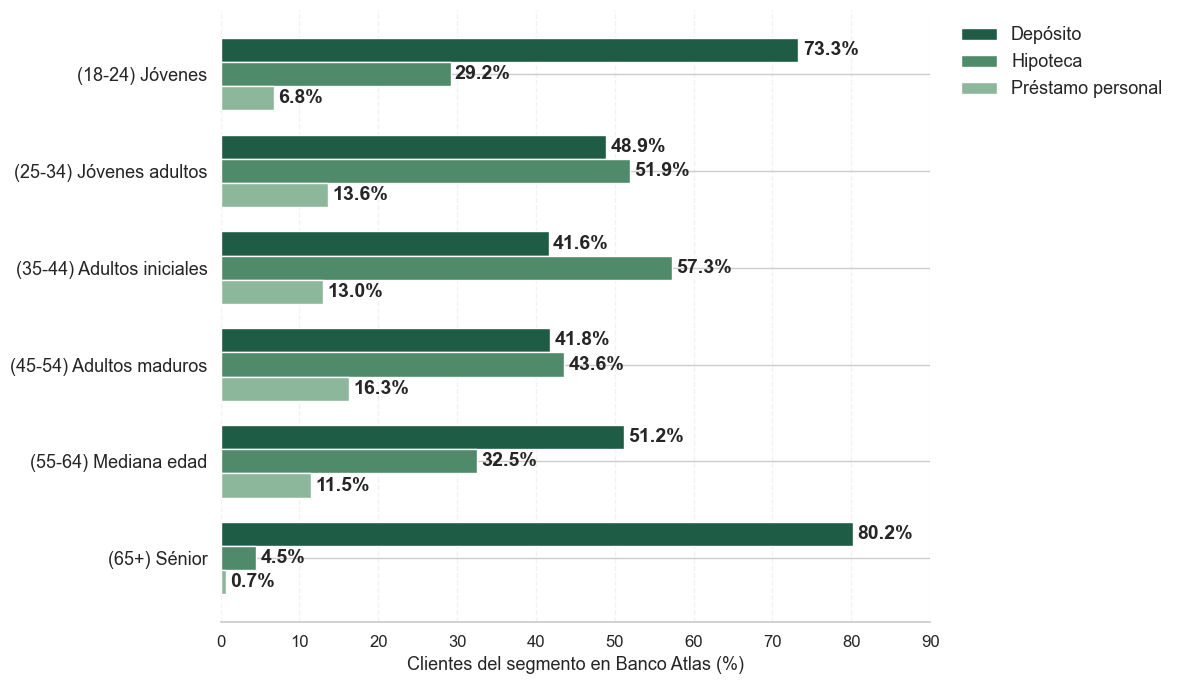

In [98]:
# =====================================================
# PRODUCTOS FINANCIEROS ACTUALES — BANCO ATLAS
# =====================================================

segmentos = tabla_resumen.index
y = np.arange(len(segmentos))
alto = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

barras_deposito = ax.barh(
    y - alto,
    tabla_resumen["Depósito (%)"],
    height=alto,
    color="#1F5C45",
    label="Depósito"
)

barras_hipoteca = ax.barh(
    y,
    tabla_resumen["Hipoteca (%)"],
    height=alto,
    color="#4F8A6A",
    label="Hipoteca"
)

barras_prestamo = ax.barh(
    y + alto,
    tabla_resumen["Préstamo (%)"],
    height=alto,
    color="#8DB79A",
    label="Préstamo personal"
)

for barras in [
    barras_deposito,
    barras_hipoteca,
    barras_prestamo
]:
    ax.bar_label(
        barras,
        fmt="%.1f%%",
        padding=3,
        fontsize=14,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(
    segmentos,
    fontsize=13
)

ax.invert_yaxis()
ax.set_xlim(0, 90)
"""
ax.set_title(
    "Productos financieros por segmento de edad",
    fontsize=17,
    fontweight="bold",
    pad=18
)
"""
ax.set_xlabel(
    "Clientes del segmento en Banco Atlas (%)",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=12
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=13
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

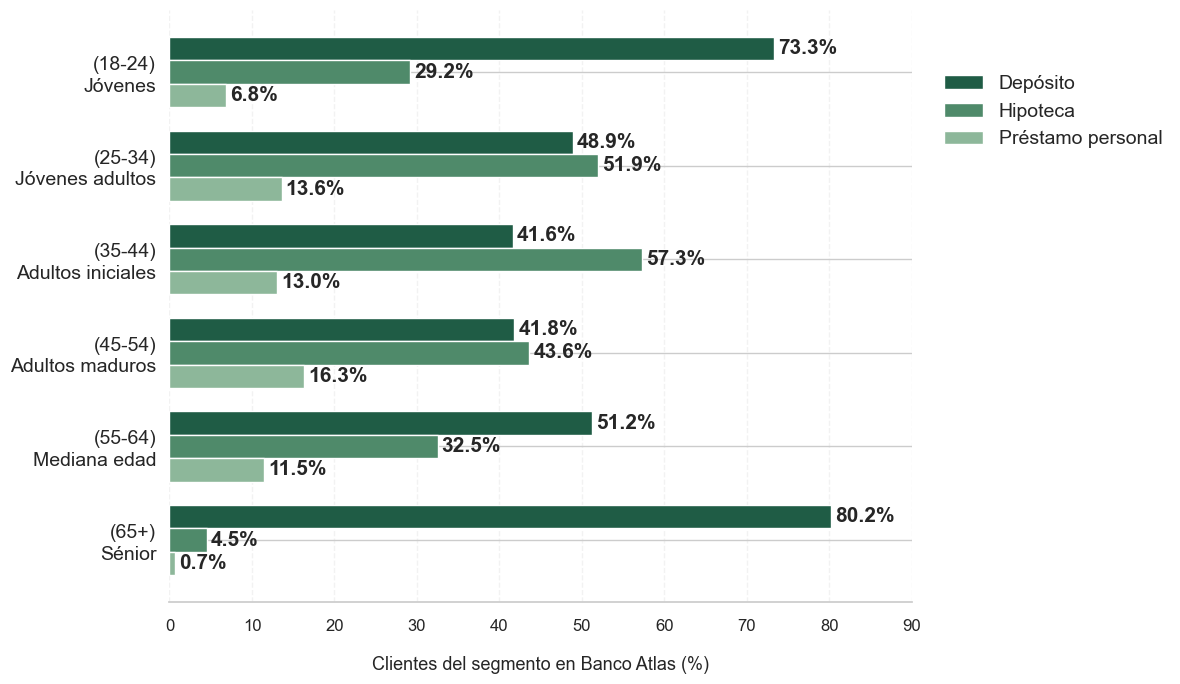

In [100]:
# =====================================================
# PRODUCTOS FINANCIEROS ACTUALES — BANCO ATLAS
# =====================================================

segmentos = tabla_resumen.index

# Segmentos en dos líneas
segmentos_2_lineas = [
    "(18-24)\nJóvenes",
    "(25-34)\nJóvenes adultos",
    "(35-44)\nAdultos iniciales",
    "(45-54)\nAdultos maduros",
    "(55-64)\nMediana edad",
    "(65+)\nSénior"
]

y = np.arange(len(segmentos))
alto = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

barras_deposito = ax.barh(
    y - alto,
    tabla_resumen["Depósito (%)"],
    height=alto,
    color="#1F5C45",
    label="Depósito"
)

barras_hipoteca = ax.barh(
    y,
    tabla_resumen["Hipoteca (%)"],
    height=alto,
    color="#4F8A6A",
    label="Hipoteca"
)

barras_prestamo = ax.barh(
    y + alto,
    tabla_resumen["Préstamo (%)"],
    height=alto,
    color="#8DB79A",
    label="Préstamo personal"
)

for barras in [
    barras_deposito,
    barras_hipoteca,
    barras_prestamo
]:
    ax.bar_label(
        barras,
        fmt="%.1f%%",
        padding=3,
        fontsize=15,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(
    segmentos_2_lineas,
    fontsize=14,
    linespacing=1.25
)

ax.invert_yaxis()
ax.set_xlim(0, 90)

"""
ax.set_title(
    "Productos financieros por segmento de edad",
    fontsize=17,
    fontweight="bold",
    pad=18
)
"""

ax.set_xlabel(
    "Clientes del segmento en Banco Atlas (%)",
    fontsize=13,
    labelpad=16
)

ax.tick_params(
    axis="x",
    labelsize=12,
    pad=6
)

ax.legend(
    bbox_to_anchor=(1.02, 0.92),
    loc="upper left",
    frameon=False,
    fontsize=14
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [56]:
# COMMON_VARS — versión correcta (independiente del bug de Roger)
COMMON_VARS = [
    "a04",      # Edad
    "a0000",    # Sexo
    "a0100",    # País de nacimiento
    "a1030",    # Estado civil
    "a1100",    # Educación
    "a1500",    # Situación laboral
    "a1510",
    "a1800",    # Ocupación CNO-2011
    "ccaaf",    # Comunidad Autónoma
]

FINANCIAL_COMPETENCIES = [
    "e0100",
    "e0500", "e0600", "e0700", "e0800", "e0900",
    "e1001", "e1002", "e1003", "e1101", "e1200",
    "e1300", "e1701", "e1702",
    "c0100", "c0300", "c0500",
    "c0200a", "c0200b", "c0200c", "c0200d", "c0200e", "c0200f",
    "c0200g", "c0200h", "c0200i", "c0200j", "c0200k",
    "c0600a", "c0600b", "c0600c", "c0600d", "c0600e", "c0600f",
    "c0600g", "c0600h", "c0600i", "c0600j", "c0600k",
    "f1100",
] + [f"b1230{letra}" for letra in "abcdefgh"]

# ATTITUDES — bloque d0101-d0117 (pendiente de confirmar con Roger si es compartido)
ATTITUDES = [f"d01{n:02d}" for n in range(1, 18)]

cols_needed = COMMON_VARS + FINANCIAL_COMPETENCIES + ATTITUDES

faltantes = [c for c in cols_needed if c not in df.columns]
print("Faltantes:", faltantes)

df_comp = df[[c for c in cols_needed if c in df.columns]].copy()

COLUMNAS_NUMERICAS = ["a04", "e0500", "e0700", "e0800"]
for col in COLUMNAS_NUMERICAS:
    df_comp[col] = pd.to_numeric(df_comp[col], errors="coerce")

print(df_comp.shape)

NameError: name 'df' is not defined

## Gráfico crecimiento población

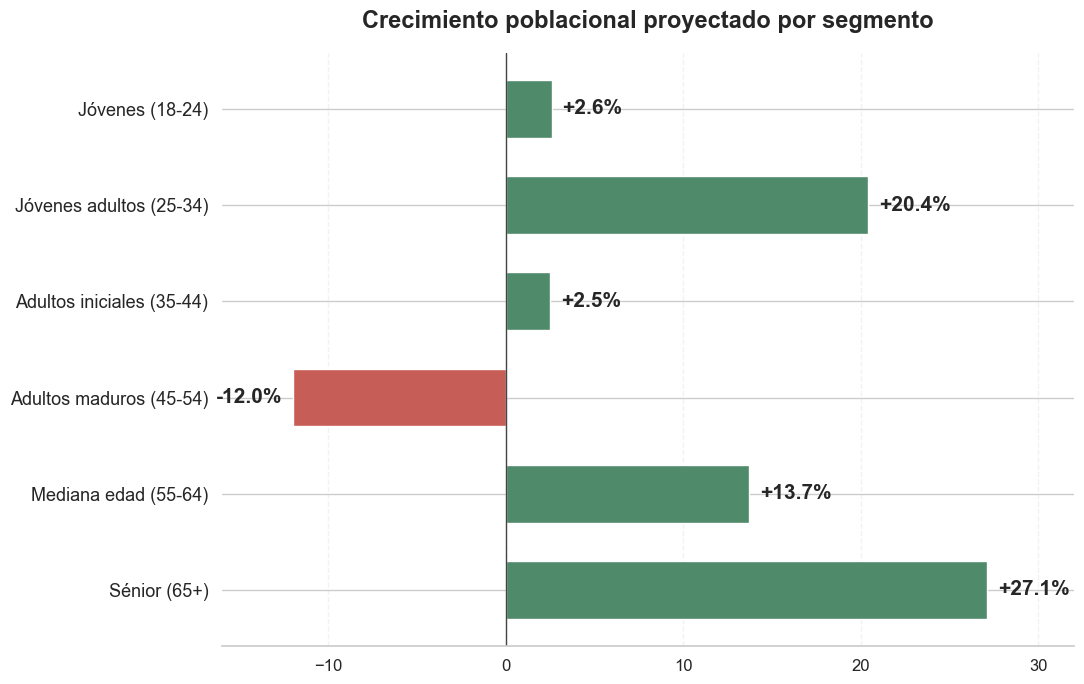

In [ ]:
# =====================================================
# CRECIMIENTO POBLACIONAL PROYECTADO — INE
# =====================================================

segmentos = tabla_resumen.index
crecimiento = tabla_resumen["Crecimiento INE (%)"]
y = np.arange(len(segmentos))

colores = [
    "#4F8A6A" if valor >= 0 else "#C65D57"
    for valor in crecimiento
]

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    y,
    crecimiento,
    height=0.60,
    color=colores
)

# Etiquetas
for barra, valor in zip(barras, crecimiento):

    posicion_y = barra.get_y() + barra.get_height() / 2

    if valor >= 0:
        ax.text(
            valor + 0.6,
            posicion_y,
            f"+{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=15,
            fontweight="bold"
        )
    else:
        ax.text(
            valor - 0.6,
            posicion_y,
            f"{valor:.1f}%",
            va="center",
            ha="right",
            fontsize=15,
            fontweight="bold"
        )

ax.axvline(
    0,
    color="#444444",
    linewidth=1
)

ax.set_yticks(y)
ax.set_yticklabels(
    segmentos,
    fontsize=13
)

ax.invert_yaxis()
ax.set_xlim(-16, 32)

ax.set_title(
    "Crecimiento poblacional proyectado por segmento",
    fontsize=17,
    fontweight="bold",
    pad=18
)
"""
ax.set_xlabel(
    "Variación proyectada por el INE, 2026–2036 (%)",
    fontsize=13
)
"""
ax.tick_params(
    axis="x",
    labelsize=12
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

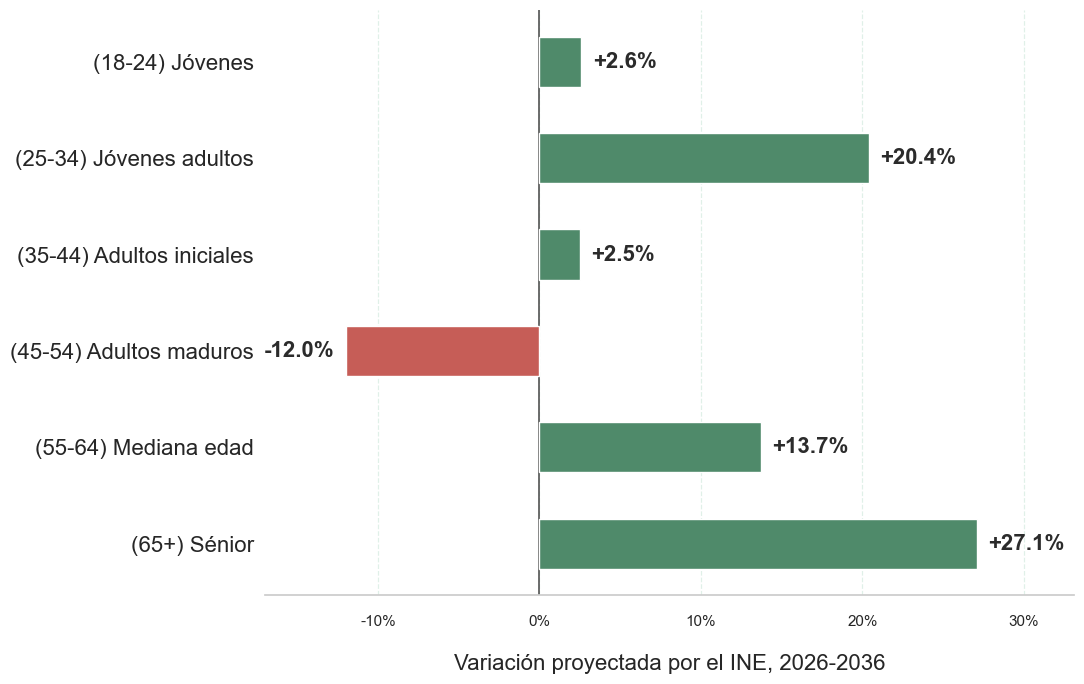

In [118]:
# =====================================================
# CRECIMIENTO POBLACIONAL PROYECTADO — INE
# =====================================================

sns.set_theme(style="white")

segmentos = tabla_resumen.index
crecimiento = tabla_resumen["Crecimiento INE (%)"]
y = np.arange(len(segmentos))

color_positivo = "#4F8A6A"
color_negativo = "#C65D57"
color_grid = "#DDEFE6"

colores = [
    color_positivo if valor >= 0 else color_negativo
    for valor in crecimiento
]

fig, ax = plt.subplots(figsize=(11, 7))

barras = ax.barh(
    y,
    crecimiento,
    height=0.52,
    color=colores,
    edgecolor="white",
    linewidth=1,
    zorder=3
)

# Línea cero
ax.axvline(
    0,
    color="#444444",
    linewidth=1.1,
    zorder=2
)

# Etiquetas de valor
for barra, valor in zip(barras, crecimiento):
    posicion_y = barra.get_y() + barra.get_height() / 2

    if valor >= 0:
        ax.text(
            valor + 0.7,
            posicion_y,
            f"+{valor:.1f}%",
            va="center",
            ha="left",
            fontsize=16,
            fontweight="bold",
            color="#2B2B2B"
        )
    else:
        ax.text(
            valor - 0.7,
            posicion_y,
            f"{valor:.1f}%",
            va="center",
            ha="right",
            fontsize=16,
            fontweight="bold",
            color="#2B2B2B"
        )

ax.set_yticks(y)
# Etiquetas: segmento grande + franja de edad debajo
etiquetas_y = [
    etiqueta.replace(" (", "\n(")
    for etiqueta in segmentos
]

ax.set_yticklabels(
    etiquetas_y,
    fontsize=16,
    linespacing=1.25
)
ax.invert_yaxis()

# Límites dinámicos con aire para etiquetas
xmin = crecimiento.min() - 5
xmax = crecimiento.max() + 6
ax.set_xlim(xmin, xmax)

# Eje X en porcentaje
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
)
"""
ax.set_title(
    "Crecimiento poblacional proyectado por segmento",
    fontsize=16,
    fontweight="bold",
    pad=16
)
"""
ax.set_xlabel(
    "Variación proyectada por el INE, 2026-2036",
    fontsize=16,
    labelpad=18
)

ax.tick_params(axis="x", labelsize=11, pad=8)
ax.tick_params(axis="y", length=0, pad=8)

# Grid solo vertical, limpio
ax.set_axisbelow(True)

ax.grid(
    axis="x",
    linestyle="--",
    color=color_grid,
    linewidth=0.9,
    alpha=0.9
)

ax.grid(axis="y", visible=False)

# Bordes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.show()